# SWH-JB-GRT — Analisa Terrain dan Luas

Notebook ini **belum menghitung kebutuhan air apa pun**. Ruang lingkupnya dua hal saja,
sesuai permintaan:

1. **Luas** — berapa hektar yang sebenarnya ada di `SWH-JB-GRT.kml`, per poligon,
   per hamparan, dan totalnya.
2. **Terrain** — ketinggian, kemiringan, arah hadap, dan arah aliran air permukaan.

Simulasi pengairan (ETo, Kc, perkolasi, debit, water loss, neraca air) **ditunda** ke
notebook berikutnya. Urutan ini bukan sekadar rapi-rapi: file ini memuat **42 poligon**
yang sebagian **bertumpuk**, dan luas yang salah akan salah dua kali lipat begitu
dipakai menghitung air.

### Sumber data

| Apa | Dari mana | Catatan |
|---|---|---|
| Batas poligon | `SWH-JB-GRT.kml` | 42 `Placemark`, dibaca apa adanya |
| Citra satelit | Esri World Imagery (Maxar, Earthstar) | hanya latar peta, tidak dipakai menghitung |
| Model elevasi (DEM) | Terrarium — AWS `elevation-tiles-prod` | turunan SRTM/ASTER, **bukan** survei lapangan |
| Cek silang elevasi | OpenTopoData (`srtm30m`, `aster30m`, `srtm90m`) | untuk mengukur ketidakpastian tegak |

### Yang perlu diketahui sebelum membaca hasilnya

> **KML ini tidak memuat data ketinggian.** Semua simpul bernilai `altitude = 0`
> (mode *clamp to ground* Google Earth), jadi terrain **tidak bisa** dibaca dari KML —
> harus diambil dari DEM luar. Diverifikasi di bagian 1.
>
> **Petak di sini jauh lebih kecil daripada satu piksel DEM.** Luas tengah (median)
> petak ~0,10 ha, sedangkan resolusi sumber DEM ~30 m (≈0,09 ha per piksel). Artinya
> satu petak rata-rata hanya diwakili **satu piksel sumber**. Angka terrain **per
> hamparan** boleh dipercaya; angka **per petak** hanya penunjuk kasar. Ini diukur di
> bagian 13, bukan dikira-kira.

## 0. Persiapan

In [1]:
import math, re, json, io as _io, socket, heapq, time, urllib.request, urllib.error
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.colors import LightSource, ListedColormap
from PIL import Image

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# ============================ KONFIGURASI ============================
NAMA_KML      = "SWH-JB-GRT.kml"
ZOOM_KONTEKS  = 16      # citra: peta ikhtisar (seluruh desa)
ZOOM_HAMPARAN = 17      # citra: seluruh lokasi kerja
ZOOM_DETAIL   = 19      # citra: rinci per hamparan (turun otomatis kalau tile kosong)
ZOOM_DEM      = 15      # DEM terrarium (zoom maksimum yang disediakan)
MARGIN_PETA   = 40.0    # m - ruang kosong di sekeliling poligon pada peta rinci
MARGIN_DEM    = 300.0   # m - DEM diambil lebih luas supaya tepi tidak bias
BEDA_KONTUR   = 2.0     # m - selang garis kontur
SLOPE_HALUS_M = 30.0    # m - skala pelaporan kemiringan (= resolusi sumber DEM)
LANGKAH_UNION = 0.5     # m - kisi penghitung luas gabungan (bagian 3)
JARAK_HAMPARAN = 60.0   # m - poligon lebih dekat dari ini dianggap satu hamparan
AMBANG_BLOK   = 0.80    # poligon yang >80% luasnya ditutupi poligon lain = batas blok
MAX_TILE      = 90
# =====================================================================

ROOT     = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
KML      = ROOT / NAMA_KML
OUT_DIR  = ROOT / "note" / "output-swh-jb-grt"; OUT_DIR.mkdir(parents=True, exist_ok=True)
GBR_DIR  = OUT_DIR / "gambar";                 GBR_DIR.mkdir(parents=True, exist_ok=True)
TILE_DIR = ROOT / "note" / "output" / "tiles";     TILE_DIR.mkdir(parents=True, exist_ok=True)
DEM_DIR  = ROOT / "note" / "output" / "tiles-dem"; DEM_DIR.mkdir(parents=True, exist_ok=True)

DPI_GAMBAR = 150
GAMBAR_TERSIMPAN = []

def simpan_gambar(fig, nama, dpi=None, dpi_tampil=None):
    """Simpan figure ke output-swh-jb-grt/gambar/*.png (150 dpi).

    `dpi_tampil` menurunkan resolusi salinan yang menempel di notebook - dipakai untuk
    peta citra satelit, yang kalau dibiarkan 110 dpi membuat berkas .ipynb membengkak
    beberapa MB per gambar. Berkas PNG-nya tetap resolusi penuh.
    """
    berkas = GBR_DIR / f"{nama}.png"
    fig.savefig(berkas, dpi=DPI_GAMBAR if dpi is None else dpi,
                bbox_inches="tight", facecolor="white")
    GAMBAR_TERSIMPAN.append(berkas)
    print(f"[gambar] {berkas.name:<34} {berkas.stat().st_size/1024:>7,.0f} KB")
    if dpi_tampil:
        fig.set_dpi(dpi_tampil)
    return berkas

assert KML.exists(), f"KML tidak ditemukan: {KML}"
print("kml    :", KML.name, f"({KML.stat().st_size:,} byte)")
print("output :", OUT_DIR)
print("gambar :", GBR_DIR)
print("tile   :", TILE_DIR, "|", DEM_DIR)

kml    : SWH-JB-GRT.kml (103,549 byte)
output : d:\WMS_AgrinIrigation\note\output-swh-jb-grt
gambar : d:\WMS_AgrinIrigation\note\output-swh-jb-grt\gambar
tile   : d:\WMS_AgrinIrigation\note\output\tiles | d:\WMS_AgrinIrigation\note\output\tiles-dem


---
## 1. Apa saja isi file KML ini?

Dibaca apa adanya dulu — semua `Placemark`, semua tipe geometri — sebelum ada asumsi.
Empat hal yang diperiksa:

1. **Ada berapa poligon, dan bernama apa?** Nomor yang bolong menandakan digitasi belum
   selesai atau ada petak yang dibuang.
2. **Nilai `altitude` tiap simpul.** Kalau semuanya `0`, KML memakai *clamp to ground*
   dan terrain **tidak ada** di dalam file — harus diambil dari DEM luar.
3. **Ada lubang (`innerBoundaryIs`)?** Lubang mengubah cara menghitung luas.
4. **Geometri selain poligon.** `Point`/`LineString` biasanya menandai bangunan atau
   saluran, dan tidak boleh ikut terhitung sebagai lahan.

In [2]:
raw = KML.read_text(encoding="utf-8")

def ambil_koordinat(blok):
    """Teks <coordinates> -> daftar (lon, lat, alt). alt = None kalau tidak ditulis."""
    out = []
    for tok in blok.split():
        bag = tok.split(",")
        if len(bag) >= 2:
            out.append((float(bag[0]), float(bag[1]),
                        float(bag[2]) if len(bag) >= 3 else None))
    return out

geometri = []
for m in re.finditer(r"<Placemark[^>]*>(.*?)</Placemark>", raw, re.S):
    body = m.group(1)
    nm   = re.search(r"<name>(.*?)</name>", body, re.S)
    nama = nm.group(1).strip() if nm else "(tanpa nama)"
    luar = re.findall(r"<outerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                      body, re.S)
    dalam = re.findall(r"<innerBoundaryIs>", body)
    if luar:
        for cd in luar:
            geometri.append({"nama": nama, "tipe": "Polygon",
                             "titik": ambil_koordinat(cd), "lubang": len(dalam)})
    else:
        for tipe in ("LineString", "Point"):
            for g in re.finditer(rf"<{tipe}>(.*?)</{tipe}>", body, re.S):
                for cd in re.finditer(r"<coordinates>(.*?)</coordinates>", g.group(1), re.S):
                    geometri.append({"nama": nama, "tipe": tipe,
                                     "titik": ambil_koordinat(cd.group(1)), "lubang": 0})

nama_dok = re.findall(r"<Document[^>]*>\s*<name>(.*?)</name>", raw, re.S)
n_placemark = len(re.findall(r"<Placemark", raw))
poligon  = [g for g in geometri if g["tipe"] == "Polygon" and len(g["titik"]) >= 4]
penanda  = [g for g in geometri if g["tipe"] == "Point"]
garis    = [g for g in geometri if g["tipe"] == "LineString"]

print(f"Nama dokumen     : {nama_dok[0] if nama_dok else '(tidak ada)'}")
print(f"Jumlah Placemark : {n_placemark}")
print(f"Jumlah geometri  : {len(geometri)}  ->  {len(poligon)} Polygon, "
      f"{len(garis)} LineString, {len(penanda)} Point")

# ---------- altitude: ada terrain di dalam KML atau tidak? ----------
alt_semua = [t[2] for g in poligon for t in g["titik"] if t[2] is not None]
tanpa_alt = sum(1 for g in poligon for t in g["titik"] if t[2] is None)
KML_PUNYA_TINGGI = bool(alt_semua) and (max(alt_semua) - min(alt_semua)) > 0.5

# ---------- nomor yang bolong ----------
nomor = sorted(int(m.group(1)) for g in poligon
               if (m := re.search(r"(\d+)$", g["nama"])))
bolong = [n for n in range(min(nomor), max(nomor)+1) if n not in nomor]

print("\n" + "=" * 74)
print(f"  Poligon        : {len(poligon)}")
print(f"  Simpul         : {sum(len(g['titik']) for g in poligon):,} total | "
      f"{min(len(g['titik']) for g in poligon)}..{max(len(g['titik']) for g in poligon)} per poligon")
print(f"  Lubang         : {sum(g['lubang'] for g in poligon)} "
      f"-> {'ada, luas harus dikurangi lubang' if sum(g['lubang'] for g in poligon) else 'tidak ada, luas = luas cincin luar'}")
if alt_semua:
    print(f"  Altitude       : {min(alt_semua):.2f} .. {max(alt_semua):.2f} m "
          f"({len(alt_semua):,} simpul bernilai, {tanpa_alt} tanpa nilai)")
print(f"  Terrain di dalam KML : {'ADA' if KML_PUNYA_TINGGI else 'TIDAK ADA'}")
if not KML_PUNYA_TINGGI:
    print("     -> semua simpul rata di 0 m (clamp to ground Google Earth).")
    print("     -> ketinggian WAJIB diambil dari DEM luar (bagian 7).")
print(f"  Nomor terpakai : {min(nomor)}..{max(nomor)}")
print(f"  Nomor BOLONG   : {bolong if bolong else '(tidak ada)'}")
if bolong:
    print("     -> penomoran tidak berurutan. Bukan kesalahan hitung: berarti ada petak")
    print("        yang belum/tidak digitasi, dan jumlah petak di lapangan bisa lebih")
    print("        banyak daripada yang ada di file ini.")
print("=" * 74)

Nama dokumen     : SWH-JB-GRT
Jumlah Placemark : 42
Jumlah geometri  : 42  ->  42 Polygon, 0 LineString, 0 Point

  Poligon        : 42
  Simpul         : 1,958 total | 11..136 per poligon
  Lubang         : 0 -> tidak ada, luas = luas cincin luar
  Altitude       : 0.00 .. 0.00 m (1,958 simpul bernilai, 0 tanpa nilai)
  Terrain di dalam KML : TIDAK ADA
     -> semua simpul rata di 0 m (clamp to ground Google Earth).
     -> ketinggian WAJIB diambil dari DEM luar (bagian 7).
  Nomor terpakai : 0..44
  Nomor BOLONG   : [5, 14, 16]
     -> penomoran tidak berurutan. Bukan kesalahan hitung: berarti ada petak
        yang belum/tidak digitasi, dan jumlah petak di lapangan bisa lebih
        banyak daripada yang ada di file ini.


---
## 2. Dari derajat ke meter, lalu luas tiap poligon

Koordinat KML satuannya **derajat**, dan 1 derajat bujur di lintang ini tidak sepanjang
1 derajat lintang. Semua titik dipindah dulu ke **meter lokal** dengan satu titik acuan
yang sama — acuan itu dipakai konsisten sampai akhir notebook, termasuk untuk citra
dan DEM.

Luas dihitung dengan **Shoelace** di bidang meter, lalu dicek-silang dengan rumus luas
**bola** (spherical excess). Yang perlu diperhatikan bukan besarnya selisih, tapi
**polanya**: lokasi ini terbentang ~1 km, jauh lebih luas daripada lahan tunggal, jadi
kalau proyeksi bidang datar mulai melenceng, selisihnya akan **membesar** untuk poligon
yang makin jauh dari titik acuan. Selisih yang **tetap** untuk semua poligon berarti
bukan distorsi proyeksi, melainkan hanya beda **konstanta skala** antara model bola dan
model elipsoid.

Konversi satuan — semuanya turun dari satu definisi: **1 ha = 10.000 m²**

In [3]:
semua_titik = [t for g in poligon for t in g["titik"]]
lon_all = np.array([t[0] for t in semua_titik]); lat_all = np.array([t[1] for t in semua_titik])
lat0, lon0 = float(lat_all.mean()), float(lon_all.mean())
phi = math.radians(lat0)
M_PER_DEG_LAT = 111_132.92 - 559.82*math.cos(2*phi) + 1.175*math.cos(4*phi)
M_PER_DEG_LON = 111_412.84*math.cos(phi) - 93.5*math.cos(3*phi)

def ke_meter(titik):
    """(lon, lat, ...) derajat -> (x, y) meter, acuan sama untuk semua geometri."""
    return [((t[0] - lon0)*M_PER_DEG_LON, (t[1] - lat0)*M_PER_DEG_LAT) for t in titik]

def ke_derajat(x, y):
    """(x, y) meter -> (lon, lat) derajat. Kebalikan ke_meter()."""
    return (np.asarray(x)/M_PER_DEG_LON + lon0, np.asarray(y)/M_PER_DEG_LAT + lat0)

def rapikan_cincin(titik):
    """Buang simpul penutup yang menduplikasi simpul pertama."""
    if len(titik) > 3 and abs(titik[0][0]-titik[-1][0]) < 1e-12 \
                      and abs(titik[0][1]-titik[-1][1]) < 1e-12:
        return titik[:-1]
    return titik

def luas_shoelace(poly):
    """Luas poligon (m2) dari daftar titik (x, y) dalam meter."""
    if len(poly) < 3:
        return 0.0
    x = np.array([p[0] for p in poly], float); y = np.array([p[1] for p in poly], float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

def pusat_poligon(poly):
    """Titik berat poligon (bukan rata-rata simpul)."""
    x = np.array([q[0] for q in poly], float); y = np.array([q[1] for q in poly], float)
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    cr = x*y2 - x2*y; A = cr.sum()/2.0
    if abs(A) < 1e-9:
        return float(x.mean()), float(y.mean())
    return float(((x+x2)*cr).sum()/(6*A)), float(((y+y2)*cr).sum()/(6*A))

def keliling(poly):
    x = np.array([p[0] for p in poly] + [poly[0][0]]); y = np.array([p[1] for p in poly] + [poly[0][1]])
    return float(np.hypot(np.diff(x), np.diff(y)).sum())

def luas_geodesik(lon_deg, lat_deg):
    """Luas di permukaan bola (m2) - cek silang untuk proyeksi lokal."""
    R = 6_371_008.8
    la = np.radians(np.asarray(lon_deg, float)); ph = np.radians(np.asarray(lat_deg, float))
    la2, ph2 = np.roll(la, -1), np.roll(ph, -1)
    return abs(np.sum((la2-la)*(2+np.sin(ph)+np.sin(ph2))) * R*R / 2.0)

# ---------- satu baris per poligon ----------
POLI = {}
baris = []
for g in poligon:
    tt   = rapikan_cincin(g["titik"])
    poly = ke_meter(tt)
    cx, cy = pusat_poligon(poly)
    a_pl = luas_shoelace(poly)
    a_geo = luas_geodesik([t[0] for t in tt], [t[1] for t in tt])
    POLI[g["nama"]] = poly
    baris.append({"petak": g["nama"], "simpul": len(tt),
                  "luas_m2": a_pl, "luas_ha": a_pl/1e4,
                  "keliling_m": keliling(poly),
                  "x_m": cx, "y_m": cy,
                  "jarak_acuan_m": math.hypot(cx, cy),
                  "luas_bola_m2": a_geo,
                  "nisbah_bola_datar": a_geo/a_pl if a_pl else np.nan})

df_poli = pd.DataFrame(baris).sort_values("luas_m2", ascending=False).reset_index(drop=True)
LUAS_NAIF = float(df_poli["luas_m2"].sum())

print("=" * 74)
print("        LUAS TIAP POLIGON (proyeksi bidang datar lokal)")
print("=" * 74)
print(f"  Poligon                    : {len(df_poli)}")
print(f"  Terkecil                   : {df_poli['luas_m2'].min():>9,.0f} m2 "
      f"({df_poli.loc[df_poli['luas_m2'].idxmin(), 'petak']})")
print(f"  Median                     : {df_poli['luas_m2'].median():>9,.0f} m2")
print(f"  Terbesar                   : {df_poli['luas_m2'].max():>9,.0f} m2 "
      f"({df_poli.loc[df_poli['luas_m2'].idxmax(), 'petak']})")
print(f"  JUMLAH LUAS (naif)         : {LUAS_NAIF:>9,.0f} m2 = {LUAS_NAIF/1e4:.4f} ha")
print("     ^ ini BELUM boleh dipakai: kalau ada poligon bertumpuk, angka ini")
print("       menghitung tanah yang sama dua kali. Diperiksa di bagian 3.")
print("-" * 74)
nis = df_poli["nisbah_bola_datar"]
print(f"  Cek silang bola vs datar   : nisbah {nis.mean():.5f} "
      f"(sebar {nis.std():.2e}, rentang {nis.max()-nis.min():.2e})")
r = np.corrcoef(df_poli['jarak_acuan_m'], nis)[0, 1]
print(f"  Korelasi nisbah vs jarak dari titik acuan : {r:+.3f}")
if nis.std() < 1e-4:
    print(f"  -> nisbah PRAKTIS SAMA untuk semua {len(df_poli)} poligon, tidak bergantung")
    print(f"     jarak. Jadi selisih {100*abs(nis.mean()-1):.2f} % itu beda konstanta skala")
    print("     (bola radius rata-rata vs elipsoid WGS84 di lintang 7,2 LS), BUKAN")
    print("     distorsi proyeksi. Proyeksi bidang datar lokal aman dipakai untuk")
    print("     seluruh lokasi ini walaupun terbentang ~1 km.")
print(f"  1 deg lintang = {M_PER_DEG_LAT:,.1f} m | 1 deg bujur = {M_PER_DEG_LON:,.1f} m")
print(f"  Titik acuan   : {abs(lat0):.6f} LS, {lon0:.6f} BT")
print("=" * 74)

df_poli[["petak", "simpul", "luas_m2", "luas_ha", "keliling_m"]].round(
    {"luas_m2": 1, "luas_ha": 4, "keliling_m": 1})

        LUAS TIAP POLIGON (proyeksi bidang datar lokal)
  Poligon                    : 42
  Terkecil                   :       127 m2 (SWH-17)
  Median                     :     1,036 m2
  Terbesar                   :    17,555 m2 (SWH-00)
  JUMLAH LUAS (naif)         :    90,021 m2 = 9.0021 ha
     ^ ini BELUM boleh dipakai: kalau ada poligon bertumpuk, angka ini
       menghitung tanah yang sama dua kali. Diperiksa di bagian 3.
--------------------------------------------------------------------------
  Cek silang bola vs datar   : nisbah 1.00428 (sebar 3.53e-06, rentang 1.63e-05)
  Korelasi nisbah vs jarak dari titik acuan : -0.249
  -> nisbah PRAKTIS SAMA untuk semua 42 poligon, tidak bergantung
     jarak. Jadi selisih 0.43 % itu beda konstanta skala
     (bola radius rata-rata vs elipsoid WGS84 di lintang 7,2 LS), BUKAN
     distorsi proyeksi. Proyeksi bidang datar lokal aman dipakai untuk
     seluruh lokasi ini walaupun terbentang ~1 km.
  1 deg lintang = 110,591.7 m | 1 deg bu

,petak,simpul,luas_m2,luas_ha,keliling_m
0,SWH-00,135,17554.7,1.7555,556.8
1,SWH-01,78,16924.2,1.6924,564.8
2,SWH-18,73,13111.5,1.3111,473.8
3,SWH-02,35,2976.4,0.2976,217.8
4,SWH-25,64,2204.9,0.2205,205.4
5,SWH-26,31,2036.1,0.2036,188.7
6,SWH-31,40,1916.8,0.1917,188.5
7,SWH-15,29,1743.1,0.1743,175.7
8,SWH-20,21,1741.5,0.1741,175.4
9,SWH-13,39,1734.5,0.1735,171.7


---
## 3. Mana batas blok, mana petak — dan berapa luas yang sebenarnya

Menjumlahkan 42 luas poligon **belum tentu** memberi luas lahan. Di berkas KML hasil
digitasi Google Earth, satu poligon besar sering digambar sebagai **batas blok** yang
melingkupi petak-petak di dalamnya. Kalau batas blok dan petak-petaknya dijumlahkan
bersama, tanah yang sama terhitung dua kali.

Karena itu tumpang tindih **dicari dulu**, tidak diasumsikan:

1. **Tumpang tindih antar-pasangan poligon** — dihitung dengan kisi 0,5 m di dalam kotak
   pembatas bersama. Dilaporkan sebagai persen dari poligon yang lebih kecil.
2. **Penggolongan otomatis.** Poligon yang **lebih dari 80 %** luasnya tertutup poligon
   lain yang lebih kecil digolongkan **batas blok**, bukan petak. Sisanya petak.
3. **Luas gabungan (union).** Semua poligon dirasterkan ke satu kisi 0,5 m, lalu dihitung
   luas yang tertutup **paling sedikit satu** poligon. Inilah luas jujurnya — tumpang
   tindih otomatis hanya dihitung sekali.

Tumpang tindih tipis beberapa persen di antara petak bersebelahan **bukan** kesalahan
yang sama: itu galengan bersama yang tergambar dua kali sewaktu digitasi, lebarnya
sekitar sejengkal. Dilaporkan tersendiri supaya tidak dicampur dengan tumpang tindih
blok yang besar.

Terakhir, ada satu cacat yang **tidak** bisa ditangkap tumpang tindih: blok yang batas
petaknya **belum digambar sama sekali**. Poligon seperti itu tidak bertumpuk dengan apa
pun, jadi lolos dari pemeriksaan di atas — tetapi ukurannya membocorkannya. Satu petak
sawah harus bisa digenangi rata, jadi luasnya terbatas. Poligon yang luasnya berkali-kali
median petak ditandai tersendiri untuk diperiksa pada peta rinci bagian 6b.

In [4]:
def dalam_poligon(px, py, poly):
    """Uji titik-di-dalam-poligon (ray casting) untuk banyak titik sekaligus."""
    px = np.asarray(px, float); py = np.asarray(py, float)
    x = np.array([q[0] for q in poly]); y = np.array([q[1] for q in poly])
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    di_dalam = np.zeros(px.shape, bool)
    for i in range(len(x)):
        if y2[i] == y[i]:
            continue
        di_dalam ^= (((y[i] > py) != (y2[i] > py)) &
                     (px < x[i] + (py - y[i])*(x2[i] - x[i])/(y2[i] - y[i])))
    return di_dalam

def kotak(poly):
    xs = [q[0] for q in poly]; ys = [q[1] for q in poly]
    return min(xs), max(xs), min(ys), max(ys)

def luas_tumpang(poly_a, poly_b, langkah=LANGKAH_UNION):
    """Luas irisan dua poligon (m2), dihitung dengan kisi di kotak pembatas bersama."""
    ax0, ax1, ay0, ay1 = kotak(poly_a); bx0, bx1, by0, by1 = kotak(poly_b)
    x0, x1 = max(ax0, bx0), min(ax1, bx1); y0, y1 = max(ay0, by0), min(ay1, by1)
    if x1 <= x0 or y1 <= y0:
        return 0.0
    gx, gy = np.meshgrid(np.arange(x0+langkah/2, x1, langkah),
                         np.arange(y0+langkah/2, y1, langkah))
    if gx.size == 0:
        return 0.0
    m = (dalam_poligon(gx.ravel(), gy.ravel(), poly_a) &
         dalam_poligon(gx.ravel(), gy.ravel(), poly_b))
    return float(m.sum()) * langkah * langkah

LUAS = {n: luas_shoelace(p) for n, p in POLI.items()}
nama_urut = sorted(LUAS, key=lambda n: -LUAS[n])

def kotak_beririsan(a, b):
    ax0, ax1, ay0, ay1 = kotak(POLI[a]); bx0, bx1, by0, by1 = kotak(POLI[b])
    return not (bx0 > ax1 or bx1 < ax0 or by0 > ay1 or by1 < ay0)

tumpang = []
for i, a in enumerate(nama_urut):
    for b in nama_urut[i+1:]:
        if not kotak_beririsan(a, b):
            continue
        ar = luas_tumpang(POLI[a], POLI[b])
        kecil = min(LUAS[a], LUAS[b])
        if ar > 0.005 * kecil:             # abaikan irisan < 0,5% (derau kisi)
            tumpang.append({"poligon_a": a, "poligon_b": b, "irisan_m2": ar,
                            "persen_thd_kecil": 100*ar/kecil})

df_tumpang = pd.DataFrame(tumpang).sort_values("irisan_m2", ascending=False).reset_index(drop=True)

def bagian_tertutup(nama, langkah=LANGKAH_UNION):
    """Fraksi luas satu poligon yang tertutup GABUNGAN poligon lain yang lebih kecil.

    Dipakai gabungan, bukan jumlah irisan: kalau petak-petak di dalam blok saling
    bertindih sedikit di galengan bersama, penjumlahan irisan akan melebihkan
    penutupan dan bisa salah menggolongkan petak biasa sebagai batas blok.
    """
    lain = [m for m in POLI if m != nama and LUAS[m] < LUAS[nama] and kotak_beririsan(nama, m)]
    if not lain:
        return 0.0
    ax0, ax1, ay0, ay1 = kotak(POLI[nama])
    gx, gy = np.meshgrid(np.arange(ax0+langkah/2, ax1, langkah),
                         np.arange(ay0+langkah/2, ay1, langkah))
    if gx.size == 0:
        return 0.0
    di = dalam_poligon(gx.ravel(), gy.ravel(), POLI[nama])
    if di.sum() == 0:
        return 0.0
    tut = np.zeros(gx.size, bool)
    for m in lain:
        tut |= dalam_poligon(gx.ravel(), gy.ravel(), POLI[m])
    return float((di & tut).sum()) / float(di.sum())

# ---------- penggolongan otomatis: blok vs petak ----------
TERTUTUP = {n: bagian_tertutup(n) for n in POLI}
BLOK  = [n for n in nama_urut if TERTUTUP[n] > AMBANG_BLOK]
PETAK = [n for n in POLI if n not in BLOK]

# ---------- luas gabungan (union) ----------
_memo_union = {}

def luas_union(nama_list, langkah=LANGKAH_UNION):
    """Luas yang tertutup PALING SEDIKIT satu poligon (m2), lewat kisi bersama.

    Tiap poligon hanya diuji di dalam kotak pembatasnya sendiri lalu di-OR-kan ke kisi
    bersama - kalau setiap poligon diuji ke seluruh kisi, biayanya melonjak sia-sia
    (lokasi ini ~1 km, kisinya jutaan sel, padahal tiap petak hanya sepersekiannya).
    """
    kunci = (tuple(sorted(nama_list)), langkah)
    if kunci in _memo_union:
        return _memo_union[kunci]
    xs = [q[0] for n in nama_list for q in POLI[n]]; ys = [q[1] for n in nama_list for q in POLI[n]]
    x0, y0 = min(xs), min(ys)
    nx = int(math.ceil((max(xs)-x0)/langkah)) + 1
    ny = int(math.ceil((max(ys)-y0)/langkah)) + 1
    ada = np.zeros((ny, nx), bool)
    for n in nama_list:
        ax0, ax1, ay0, ay1 = kotak(POLI[n])
        j0 = max(0, int((ax0-x0)/langkah)); j1 = min(nx, int(math.ceil((ax1-x0)/langkah))+1)
        i0 = max(0, int((ay0-y0)/langkah)); i1 = min(ny, int(math.ceil((ay1-y0)/langkah))+1)
        if j1 <= j0 or i1 <= i0:
            continue
        gx, gy = np.meshgrid(x0 + (np.arange(j0, j1)+0.5)*langkah,
                             y0 + (np.arange(i0, i1)+0.5)*langkah)
        ada[i0:i1, j0:j1] |= dalam_poligon(gx.ravel(), gy.ravel(),
                                           POLI[n]).reshape(gx.shape)
    hasil = float(ada.sum()) * langkah * langkah
    _memo_union[kunci] = hasil
    return hasil

LUAS_UNION       = luas_union(list(POLI))
LUAS_UNION_PETAK = luas_union(PETAK)
LUAS_PETAK_NAIF  = sum(LUAS[n] for n in PETAK)

print("=" * 78)
print("             TUMPANG TINDIH ANTAR-POLIGON")
print("=" * 78)
print(f"  Pasangan beririsan (>0,5 % poligon kecil) : {len(df_tumpang)}")
besar = df_tumpang[df_tumpang["persen_thd_kecil"] > 50]
tipis = df_tumpang[df_tumpang["persen_thd_kecil"] <= 50]
print(f"    - irisan BESAR (>50 %)  : {len(besar)} pasangan, "
      f"{besar['irisan_m2'].sum():,.0f} m2  <- tanda batas blok")
print(f"    - irisan tipis (<=50 %) : {len(tipis)} pasangan, "
      f"{tipis['irisan_m2'].sum():,.0f} m2  <- galengan bersama tergambar dua kali")
if len(tipis):
    print(f"      (terbesar {tipis['persen_thd_kecil'].max():.1f} % dari petak kecil "
          f"= {tipis['irisan_m2'].max():.1f} m2)")
print("-" * 78)
print(f"  Digolongkan BATAS BLOK ({len(BLOK)}) : {', '.join(BLOK) if BLOK else '(tidak ada)'}")
for n in BLOK:
    anak = [b for a, b in zip(df_tumpang["poligon_a"], df_tumpang["poligon_b"]) if a == n]
    print(f"     {n}: luas {LUAS[n]/1e4:.4f} ha, {100*TERTUTUP[n]:.1f} % tertutup "
          f"{len(anak)} petak di dalamnya ({sum(LUAS[x] for x in anak)/1e4:.4f} ha)")
    print(f"        sisa {LUAS[n]*(1-TERTUTUP[n])/1e4:.4f} ha = galengan/jalan di dalam blok "
          f"yang belum dijadikan petak")
print(f"  Digolongkan PETAK : {len(PETAK)}")
tt = sorted((TERTUTUP[n] for n in PETAK), reverse=True)[:1]
print(f"     penutupan tertinggi di antara petak: {100*tt[0]:.1f} % "
      f"(ambang blok {100*AMBANG_BLOK:.0f} %) -> penggolongannya tidak di batas ambang")
print("=" * 78)
print("                      LUAS — ANGKA YANG BOLEH DIPAKAI")
print("=" * 78)
print(f"  Jumlah naif 42 poligon        : {LUAS_NAIF:>10,.0f} m2 = {LUAS_NAIF/1e4:>7.4f} ha  <- SALAH")
print(f"  Luas gabungan (union) semua   : {LUAS_UNION:>10,.0f} m2 = {LUAS_UNION/1e4:>7.4f} ha  <- BENAR")
print(f"  Selisih (terhitung dua kali)  : {LUAS_NAIF-LUAS_UNION:>10,.0f} m2 = "
      f"{(LUAS_NAIF-LUAS_UNION)/1e4:>7.4f} ha  ({100*(LUAS_NAIF-LUAS_UNION)/LUAS_UNION:.1f} %)")
print("-" * 78)
print(f"  Luas {len(PETAK)} petak (jumlah)      : {LUAS_PETAK_NAIF:>10,.0f} m2 = "
      f"{LUAS_PETAK_NAIF/1e4:>7.4f} ha")
print(f"  Luas {len(PETAK)} petak (union)       : {LUAS_UNION_PETAK:>10,.0f} m2 = "
      f"{LUAS_UNION_PETAK/1e4:>7.4f} ha  <- luas SAWAH yang diairi")
print(f"  Galengan bersama tergambar 2x : {LUAS_PETAK_NAIF-LUAS_UNION_PETAK:>10,.0f} m2 "
      f"({100*(LUAS_PETAK_NAIF-LUAS_UNION_PETAK)/LUAS_UNION_PETAK:.2f} % - dapat diabaikan)")
print(f"  Di dalam blok, belum jadi petak: {LUAS_UNION-LUAS_UNION_PETAK:>10,.0f} m2 = "
      f"{(LUAS_UNION-LUAS_UNION_PETAK)/1e4:>7.4f} ha")
print("=" * 78)

# ---------- petak yang kelewat besar untuk disebut satu petak ----------
AMBANG_RAKSASA = 5.0
MEDIAN_PETAK = float(np.median([LUAS[n] for n in PETAK]))
RAKSASA = sorted([n for n in PETAK if LUAS[n] > AMBANG_RAKSASA*MEDIAN_PETAK],
                 key=lambda n: -LUAS[n])
print("           POLIGON YANG TERLALU BESAR UNTUK DISEBUT SATU PETAK")
print("=" * 78)
print(f"  Luas petak median : {MEDIAN_PETAK:,.0f} m2. Poligon di atas "
      f"{AMBANG_RAKSASA:.0f}x median ({AMBANG_RAKSASA*MEDIAN_PETAK:,.0f} m2) ditandai:")
if RAKSASA:
    for n in RAKSASA:
        print(f"     {n}: {LUAS[n]/1e4:.4f} ha = {LUAS[n]/MEDIAN_PETAK:.0f}x median petak")
    tot_r = sum(LUAS[n] for n in RAKSASA)
    print(f"  Jumlah : {tot_r/1e4:.4f} ha = {100*tot_r/LUAS_UNION_PETAK:.0f} % dari seluruh "
          f"luas petak, hanya dalam {len(RAKSASA)} poligon.")
    print("  Petak sawah sebesar itu praktis tidak ada - satu petak harus bisa digenangi")
    print("  rata. Periksa peta rinci bagian 6b: kalau di dalamnya tampak galengan,")
    print("  poligon ini sebenarnya BLOK yang belum dibagi petak, sama seperti "
          f"{BLOK[0] if BLOK else 'batas blok'},")
    print("  hanya saja batas petaknya belum digambar sama sekali sehingga tidak")
    print("  terdeteksi dari tumpang tindih.")
    print(f"  Akibatnya: hitungan air per petak baru bisa lengkap untuk "
          f"{100*(LUAS_UNION_PETAK-tot_r)/LUAS_UNION_PETAK:.0f} % luas;")
    print(f"  sisanya ({100*tot_r/LUAS_UNION_PETAK:.0f} %) hanya bisa dihitung sebagai satu "
          "hamparan besar.")
else:
    print("     (tidak ada) -> ukuran petak seragam, semua wajar sebagai satu petak.")
print("=" * 78)
df_tumpang.round({"irisan_m2": 1, "persen_thd_kecil": 1})

             TUMPANG TINDIH ANTAR-POLIGON
  Pasangan beririsan (>0,5 % poligon kecil) : 15
    - irisan BESAR (>50 %)  : 8 pasangan, 11,578 m2  <- tanda batas blok
    - irisan tipis (<=50 %) : 7 pasangan, 98 m2  <- galengan bersama tergambar dua kali
      (terbesar 3.2 % dari petak kecil = 35.8 m2)
------------------------------------------------------------------------------
  Digolongkan BATAS BLOK (1) : SWH-18
     SWH-18: luas 1.3111 ha, 88.2 % tertutup 8 petak di dalamnya (1.1713 ha)
        sisa 0.1553 ha = galengan/jalan di dalam blok yang belum dijadikan petak
  Digolongkan PETAK : 41
     penutupan tertinggi di antara petak: 2.6 % (ambang blok 80 %) -> penggolongannya tidak di batas ambang
                      LUAS — ANGKA YANG BOLEH DIPAKAI
  Jumlah naif 42 poligon        :     90,021 m2 =  9.0021 ha  <- SALAH
  Luas gabungan (union) semua   :     78,331 m2 =  7.8331 ha  <- BENAR
  Selisih (terhitung dua kali)  :     11,690 m2 =  1.1690 ha  (14.9 %)
-----------------------

,poligon_a,poligon_b,irisan_m2,persen_thd_kecil
0,SWH-18,SWH-25,2196.0,99.6
1,SWH-18,SWH-26,1927.0,94.6
2,SWH-18,SWH-20,1726.8,99.2
3,SWH-18,SWH-24,1687.8,100.1
4,SWH-18,SWH-21,1387.2,99.8
5,SWH-18,SWH-19,1351.0,99.8
6,SWH-18,SWH-22,667.8,99.8
7,SWH-18,SWH-23,634.0,100.3
8,SWH-07,SWH-06,35.8,3.2
9,SWH-08,SWH-09,16.2,2.0


---
## 4. Hamparan — poligon mana yang satu kesatuan

42 poligon ini **tidak** satu hamparan. Sebelum terrain dibaca, poligon dikelompokkan
dulu menurut kedekatan: poligon yang tepinya berjarak kurang dari ambang tertentu
digabung jadi satu kelompok (*single linkage*), dan kelompok itulah yang disebut
**hamparan**.

Kenapa ini harus dikerjakan lebih dulu: kalau seluruh lokasi dianggap satu lahan,
beda tinggi yang terbaca sebagian besar adalah beda tinggi **antar hamparan yang
letaknya berjauhan** — bukan kemiringan di dalam sawah. Angka itu benar secara
aritmetika tetapi menyesatkan untuk irigasi, karena air tidak mengalir dari satu
hamparan ke hamparan lain yang terpisah 400 m.

Ambang jaraknya tidak dikarang: dicoba dari 20 m sampai 200 m, lalu dipakai nilai yang
berada di **dataran stabil** — rentang ambang yang menghasilkan jumlah kelompok sama.
Pengelompokan yang berubah-ubah mengikuti ambang berarti tidak ada batas alami.

In [5]:
nama_poli = list(POLI)
n_poli = len(nama_poli)
ARR = {n: np.array(POLI[n], float) for n in nama_poli}

# jarak tepi-ke-tepi (didekati dengan jarak simpul terdekat)
JARAK = np.zeros((n_poli, n_poli))
for i in range(n_poli):
    for j in range(i+1, n_poli):
        a, b = ARR[nama_poli[i]], ARR[nama_poli[j]]
        d = float(np.sqrt(((a[:, None, :] - b[None, :, :])**2).sum(-1)).min())
        JARAK[i, j] = JARAK[j, i] = d

def kelompokkan(ambang):
    """Single linkage: satu kelompok = poligon yang terhubung lewat jarak <= ambang."""
    lab = -np.ones(n_poli, int); k = 0
    for i in range(n_poli):
        if lab[i] >= 0:
            continue
        tumpuk = [i]; lab[i] = k
        while tumpuk:
            a = tumpuk.pop()
            for j in range(n_poli):
                if lab[j] < 0 and JARAK[a, j] <= ambang:
                    lab[j] = k; tumpuk.append(j)
        k += 1
    return lab, k

print("Uji kestabilan ambang jarak:")
for th in (10, 20, 30, 40, 60, 80, 120, 160, 200, 300):
    lab, k = kelompokkan(th)
    ukuran = sorted((int((lab == g).sum()) for g in range(k)), reverse=True)
    tanda = "  <- dipakai" if th == JARAK_HAMPARAN else ""
    print(f"  ambang {th:>4} m -> {k} kelompok, ukuran {ukuran}{tanda}")

LABEL, N_HAM = kelompokkan(JARAK_HAMPARAN)
print(f"\nAmbang {JARAK_HAMPARAN:.0f} m berada di dataran stabil "
      f"(30-160 m menghasilkan {N_HAM} kelompok yang sama) -> batas hamparannya alami.")

# Urutkan hamparan dari yang terluas, beri nama H1, H2, ... Dipakai luas GABUNGAN,
# bukan jumlah luas poligon: kalau dijumlahkan, hamparan yang punya batas blok akan
# tampak lebih luas daripada kenyataannya dan urutan namanya jadi menyesatkan.
urut_ham = sorted(range(N_HAM),
                  key=lambda g: -luas_union([nama_poli[i] for i in range(n_poli)
                                             if LABEL[i] == g]))
HAMPARAN = {}
for k, g in enumerate(urut_ham, start=1):
    HAMPARAN[f"H{k}"] = [nama_poli[i] for i in range(n_poli) if LABEL[i] == g]
HAM_DARI = {n: h for h, mem in HAMPARAN.items() for n in mem}

baris = []
for h, mem in HAMPARAN.items():
    xs = [q[0] for n in mem for q in POLI[n]]; ys = [q[1] for n in mem for q in POLI[n]]
    pk = [n for n in mem if n in PETAK]
    baris.append({"hamparan": h, "n_poligon": len(mem), "n_petak": len(pk),
                  "n_blok": len(mem)-len(pk),
                  "luas_union_ha": luas_union(mem)/1e4,
                  "luas_petak_ha": (luas_union(pk)/1e4) if pk else 0.0,
                  "bentang_bt_m": max(xs)-min(xs), "bentang_us_m": max(ys)-min(ys),
                  "anggota": ", ".join(sorted(mem))})
df_ham = pd.DataFrame(baris)

# jarak antar hamparan (tepi terdekat)
print("\n" + "=" * 78)
print("                    HAMPARAN — HASIL PENGELOMPOKAN")
print("=" * 78)
for _, r in df_ham.iterrows():
    print(f"  {r['hamparan']}: {r['n_poligon']:>2} poligon ({r['n_petak']} petak"
          f"{f' + {r.n_blok} batas blok' if r['n_blok'] else ''})"
          f" | {r['luas_union_ha']:.4f} ha | bentang {r['bentang_bt_m']:.0f} x {r['bentang_us_m']:.0f} m")
    print(f"      {r['anggota']}")
print("-" * 78)
print(f"  Jumlah luas hamparan : {df_ham['luas_union_ha'].sum():.4f} ha "
      f"(union seluruh lokasi {LUAS_UNION/1e4:.4f} ha -> "
      f"{'cocok' if abs(df_ham['luas_union_ha'].sum()-LUAS_UNION/1e4) < 0.01 else 'PERIKSA'})")
print("  Jarak antar hamparan terdekat:")
for i, h1 in enumerate(list(HAMPARAN)):
    for h2 in list(HAMPARAN)[i+1:]:
        d = min(JARAK[nama_poli.index(a), nama_poli.index(b)]
                for a in HAMPARAN[h1] for b in HAMPARAN[h2])
        print(f"     {h1} - {h2} : {d:>6.0f} m")
print("=" * 78)
df_ham.drop(columns=["anggota"]).round(4)

Uji kestabilan ambang jarak:
  ambang   10 m -> 5 kelompok, ukuran [15, 13, 12, 1, 1]
  ambang   20 m -> 5 kelompok, ukuran [15, 13, 12, 1, 1]
  ambang   30 m -> 5 kelompok, ukuran [15, 13, 12, 1, 1]
  ambang   40 m -> 4 kelompok, ukuran [27, 13, 1, 1]
  ambang   60 m -> 4 kelompok, ukuran [27, 13, 1, 1]  <- dipakai
  ambang   80 m -> 4 kelompok, ukuran [27, 13, 1, 1]
  ambang  120 m -> 4 kelompok, ukuran [27, 13, 1, 1]
  ambang  160 m -> 3 kelompok, ukuran [40, 1, 1]
  ambang  200 m -> 2 kelompok, ukuran [41, 1]
  ambang  300 m -> 2 kelompok, ukuran [41, 1]

Ambang 60 m berada di dataran stabil (30-160 m menghasilkan 4 kelompok yang sama) -> batas hamparannya alami.

                    HAMPARAN — HASIL PENGELOMPOKAN
  H1: 13 poligon (13 petak) | 3.2020 ha | bentang 339 x 203 m
      SWH-00, SWH-02, SWH-03, SWH-04, SWH-06, SWH-07, SWH-08, SWH-09, SWH-10, SWH-11, SWH-12, SWH-13, SWH-15
  H2: 27 poligon (26 petak + 1 batas blok) | 2.9264 ha | bentang 377 x 211 m
      SWH-18, SWH-19, SW

,hamparan,n_poligon,n_petak,n_blok,luas_union_ha,luas_petak_ha,bentang_bt_m,bentang_us_m
0,H1,13,13,0,3.2020,3.2020,338.6131,202.5470
1,H2,27,26,1,2.9264,2.7712,377.2921,211.2306
2,H3,1,1,0,1.6925,1.6925,149.5360,184.5262
3,H4,1,1,0,0.0128,0.0128,15.5613,15.3701


---
## 5. Peta dasar dari citra satelit

Citra diambil sebagai *tile* Esri World Imagery dan disusun jadi satu gambar, lalu
dipasang pada sumbu **meter lokal** yang sama dengan poligon — supaya batas KML dan
citra benar-benar bertumpuk, bukan sekadar berdampingan.

Tile disimpan ke `note/output/tiles/`, jadi hanya diunduh sekali. Kalau jaringan mati,
peta tetap digambar tanpa citra.

> **Zoom tertinggi belum tentu ada citranya.** Untuk zoom yang belum diliput, Esri tidak
> mengembalikan error — melainkan **HTTP 200 berisi pelat abu-abu** *"Map data not yet
> available"*. Kalau hanya mengandalkan `try/except`, pelat itu akan lolos dan terpasang
> sebagai "peta". Karena itu isi tiap tile diperiksa: pelat kosong praktis tanpa warna
> dan tanpa variasi. Kalau kedapatan kosong, zoom diturunkan satu tingkat dan pelat
> tersebut **tidak** ikut disimpan ke cache.

In [6]:
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT   = "Citra: Esri, Maxar, Earthstar Geographics"
UA       = {"User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"}

def lonlat_ke_piksel(lo, la, z):
    n = 256 * 2**z
    return ((lo+180.0)/360.0*n,
            (1.0 - math.log(math.tan(math.radians(la)) +
                            1.0/math.cos(math.radians(la)))/math.pi)/2.0*n)

def piksel_ke_lonlat(px, py, z):
    n = 256 * 2**z
    return (px/n*360.0 - 180.0,
            math.degrees(math.atan(math.sinh(math.pi*(1.0 - 2.0*py/n)))))

def meter_per_piksel(z):
    return 40_075_016.686 * math.cos(phi) / 2**z / 256

class TileKosong(RuntimeError):
    """Tile terunduh tapi isinya pelat 'Map data not yet available'."""

def tile_kosong(img):
    """Pelat kosong Esri: praktis tanpa warna (R=G=B) dan nyaris tanpa variasi."""
    a = img.astype(np.int16)
    tanpa_warna = ((a.max(axis=2) - a.min(axis=2)) < 8).mean()
    return tanpa_warna > 0.90 and a.std() < 12

def ambil_tile(z, x, y, timeout=25):
    f = TILE_DIR / f"{z}_{x}_{y}.jpg"
    if f.exists():
        img = np.asarray(Image.open(f).convert("RGB"))
        if tile_kosong(img):
            f.unlink()                      # buang pelat kosong yang terlanjur tersimpan
            raise TileKosong(f"z{z} belum punya citra di lokasi ini")
        return img
    with urllib.request.urlopen(urllib.request.Request(TILE_URL.format(z=z, x=x, y=y),
                                                       headers=UA), timeout=timeout) as r:
        d = r.read()
    img = np.asarray(Image.open(_io.BytesIO(d)).convert("RGB"))
    if tile_kosong(img):
        raise TileKosong(f"z{z} belum punya citra di lokasi ini")
    f.write_bytes(d)                        # hanya tile berisi citra yang dicache
    return img

def susun_basemap(z, x0m, x1m, y0m, y1m, margin_m):
    """Susun citra yang menutupi kotak meter + margin. -> (kanvas, extent meter, n_tile)."""
    lo0, la1 = ke_derajat(x0m - margin_m, y1m + margin_m)
    lo1, la0 = ke_derajat(x1m + margin_m, y0m - margin_m)
    px0, py0 = lonlat_ke_piksel(float(lo0), float(la1), z)
    px1, py1 = lonlat_ke_piksel(float(lo1), float(la0), z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    n_tile = (tx1-tx0+1)*(ty1-ty0+1)
    if n_tile > MAX_TILE:
        raise RuntimeError(f"butuh {n_tile} tile (batas {MAX_TILE})")
    kanvas = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), dtype=np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            kanvas[(ty-ty0)*256:(ty-ty0+1)*256,
                   (tx-tx0)*256:(tx-tx0+1)*256] = ambil_tile(z, tx, ty)[:, :, :3]
    lk, la_ = piksel_ke_lonlat(tx0*256, ty0*256, z)
    lka, lb = piksel_ke_lonlat((tx1+1)*256, (ty1+1)*256, z)
    return kanvas, [(lk-lon0)*M_PER_DEG_LON, (lka-lon0)*M_PER_DEG_LON,
                    (lb-lat0)*M_PER_DEG_LAT, (la_-lat0)*M_PER_DEG_LAT], n_tile

X_ALL = np.array([q[0] for p in POLI.values() for q in p])
Y_ALL = np.array([q[1] for p in POLI.values() for q in p])
CX_ALL, CY_ALL = float(X_ALL.mean()), float(Y_ALL.mean())

socket.setdefaulttimeout(35)
CITRA = {}

def siapkan_citra(label, zoom, kotak_m, margin):
    x0m, x1m, y0m, y1m = kotak_m
    for zz in (zoom, zoom-1, zoom-2):
        try:
            img, ext, n = susun_basemap(zz, x0m, x1m, y0m, y1m, margin)
            CITRA[label] = {"img": img, "extent": ext, "zoom": zz, "n_tile": n}
            print(f"[{label:<10}] z{zz} | {img.shape[1]}x{img.shape[0]} px dari {n:>2} tile "
                  f"| {meter_per_piksel(zz):.2f} m/piksel")
            return
        except Exception as e:
            print(f"[{label:<10}] z{zz} gagal ({type(e).__name__}: {e}) - coba zoom lebih rendah")
    CITRA[label] = None
    print(f"[{label:<10}] citra tidak tersedia - peta digambar tanpa latar")

siapkan_citra("konteks", ZOOM_KONTEKS,
              (X_ALL.min(), X_ALL.max(), Y_ALL.min(), Y_ALL.max()), 650.0)
siapkan_citra("lokasi", ZOOM_HAMPARAN,
              (X_ALL.min(), X_ALL.max(), Y_ALL.min(), Y_ALL.max()), 60.0)
for h, mem in HAMPARAN.items():
    xs = [q[0] for n in mem for q in POLI[n]]; ys = [q[1] for n in mem for q in POLI[n]]
    siapkan_citra(h, ZOOM_DETAIL, (min(xs), max(xs), min(ys), max(ys)), MARGIN_PETA)

ADA_CITRA = CITRA.get("lokasi") is not None
print("\n" + (KREDIT if ADA_CITRA else "(tanpa citra satelit)"))

[konteks   ] z16 | 1280x1280 px dari 25 tile | 2.37 m/piksel
[lokasi    ] z17 | 1024x1280 px dari 20 tile | 1.18 m/piksel
[H1        ] z19 | 1792x1280 px dari 35 tile | 0.30 m/piksel


[H2        ] z19 | 1792x1280 px dari 35 tile | 0.30 m/piksel
[H3        ] z19 | 1024x1024 px dari 16 tile | 0.30 m/piksel
[H4        ] z19 | 512x768 px dari  6 tile | 0.30 m/piksel

Citra: Esri, Maxar, Earthstar Geographics


---
## 6. Overlay: batas poligon di atas citra

Lihat dulu, hitung belakangan. Dua panel: **konteks** (di mana lokasi ini berada) dan
**seluruh lokasi** (empat hamparan sekaligus, diwarnai per hamparan). Batas blok
digambar putus-putus supaya bedanya dengan petak terlihat langsung.

[gambar] 01_overlay_citra.png                 4,269 KB


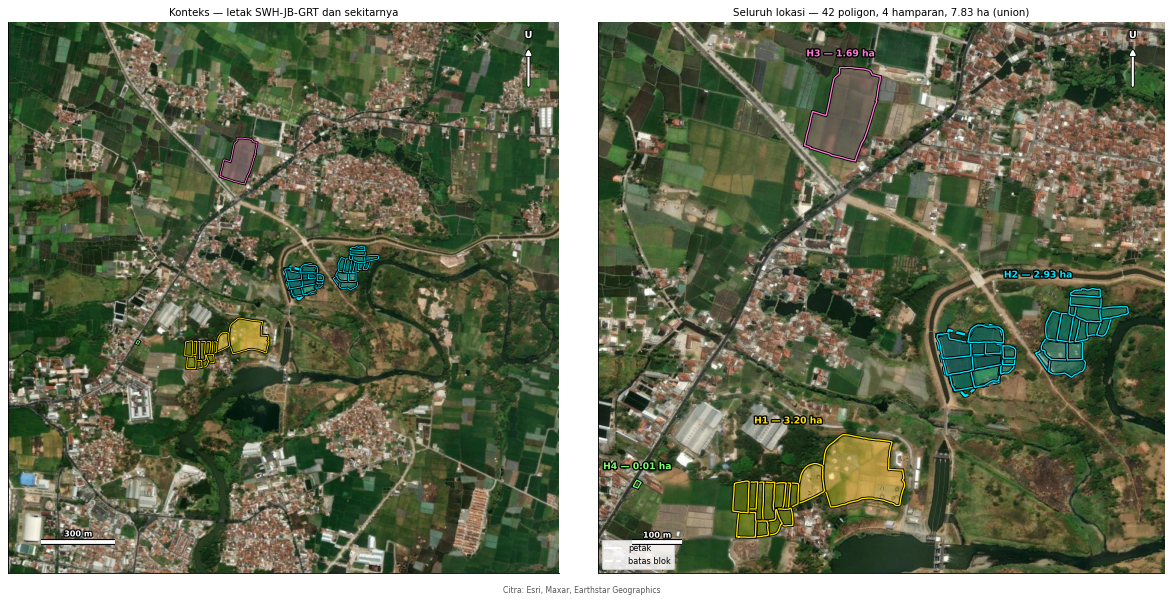

In [7]:
WARNA_HAM = ["#ffe400", "#00e5ff", "#ff7bd5", "#7cff6b", "#ffa23c", "#c39bff"]
W_HAM = {h: WARNA_HAM[i % len(WARNA_HAM)] for i, h in enumerate(HAMPARAN)}

# Garis tepi dipilih berlawanan dengan warna isian - kalau keduanya hitam (peta berlatar
# terang), tulisan skala tenggelam di batangnya sendiri dan tidak terbaca.
_tepi = lambda w: "white" if w in ("black", "#000000") else "black"

def batang_skala(ax, x0, y0, panjang_m, warna="white"):
    tp = _tepi(warna)
    ax.plot([x0, x0+panjang_m], [y0, y0], color=warna, lw=3.5, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.5, foreground=tp)], zorder=9)
    ax.text(x0+panjang_m/2, y0+panjang_m*0.055, f"{panjang_m:.0f} m", ha="center",
            va="bottom", fontsize=7.5, color=warna, weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground=tp)])

def panah_utara(ax, frac_x=0.945, frac_y=0.88, panjang=0.075, warna="white"):
    tp = _tepi(warna)
    ax.annotate("", xy=(frac_x, frac_y+panjang), xytext=(frac_x, frac_y),
                xycoords="axes fraction", zorder=9,
                arrowprops=dict(arrowstyle="-|>", color=warna, lw=2,
                                path_effects=[pe.withStroke(linewidth=3.5,
                                                            foreground=tp)]))
    ax.text(frac_x, frac_y+panjang+0.012, "U", transform=ax.transAxes, ha="center",
            va="bottom", fontsize=9, color=warna, weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground=tp)])

def pasang_citra(ax, label):
    c = CITRA.get(label)
    if c is not None:
        ax.imshow(c["img"], extent=c["extent"], origin="upper",
                  interpolation="bilinear", zorder=0)
    else:
        ax.set_facecolor("#e8e8e8")
    return c

def gambar_poligon(ax, nama_list, isi=0.18, lw_petak=1.6, label_petak=False, fs=6.0):
    # Tepi diberi garis hitam tipis di belakangnya: tanpa itu, poligon yang kebetulan
    # jatuh di atas tanah berwarna mirip (mis. sawah bera yang kemerahan) praktis
    # menghilang dari peta walaupun sebenarnya tergambar.
    tepi = [pe.withStroke(linewidth=lw_petak+1.6, foreground="black")]
    for n in nama_list:
        h = HAM_DARI[n]; w = W_HAM[h]
        if n in BLOK:
            ax.add_patch(MplPolygon(POLI[n], closed=True, facecolor="none", edgecolor=w,
                                    lw=2.2, ls="--", zorder=4,
                                    path_effects=[pe.withStroke(linewidth=4.0,
                                                                foreground="black")]))
        else:
            ax.add_patch(MplPolygon(POLI[n], closed=True, facecolor=w, alpha=isi,
                                    edgecolor="none", zorder=3))
            ax.add_patch(MplPolygon(POLI[n], closed=True, facecolor="none", edgecolor=w,
                                    lw=lw_petak, zorder=5, path_effects=tepi))
        if label_petak and n not in BLOK:
            cx, cy = pusat_poligon(POLI[n])
            ax.text(cx, cy, n.replace("SWH-", ""), fontsize=fs, color="white",
                    ha="center", va="center", zorder=8, weight="bold",
                    path_effects=[pe.withStroke(linewidth=1.8, foreground="black")])

def rapikan(ax, judul, xlim, ylim, skala, kiri=True):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    batang_skala(ax, xlim[0] + (0.06 if kiri else 0.72)*(xlim[1]-xlim[0]),
                 ylim[0] + 0.055*(ylim[1]-ylim[0]), skala)
    panah_utara(ax)

fig, axes = plt.subplots(1, 2, figsize=(15.4, 7.6))

# --- panel kiri: konteks ---
ax = axes[0]; pasang_citra(ax, "konteks")
gambar_poligon(ax, list(POLI), isi=0.30, lw_petak=0.8)
R = 0.5*max(X_ALL.max()-X_ALL.min(), Y_ALL.max()-Y_ALL.min()) + 620
rapikan(ax, "Konteks — letak SWH-JB-GRT dan sekitarnya",
        (CX_ALL-R, CX_ALL+R), (CY_ALL-R, CY_ALL+R), 300)

# --- panel kanan: seluruh lokasi ---
ax = axes[1]; pasang_citra(ax, "lokasi")
gambar_poligon(ax, list(POLI), isi=0.22, lw_petak=1.2)
for h, mem in HAMPARAN.items():
    xs = [q[0] for n in mem for q in POLI[n]]; ys = [q[1] for n in mem for q in POLI[n]]
    ax.text(np.mean(xs), max(ys)+18, f"{h} — {luas_union(mem)/1e4:.2f} ha",
            ha="center", va="bottom", fontsize=8.5, color=W_HAM[h], weight="bold",
            zorder=9, path_effects=[pe.withStroke(linewidth=2.4, foreground="black")])
rapikan(ax, f"Seluruh lokasi — {len(POLI)} poligon, {len(HAMPARAN)} hamparan, "
        f"{LUAS_UNION/1e4:.2f} ha (union)",
        (X_ALL.min()-70, X_ALL.max()+70), (Y_ALL.min()-70, Y_ALL.max()+90), 100)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color="white", lw=1.6, label="petak"),
                   Line2D([], [], color="white", lw=2.0, ls="--", label="batas blok")],
          loc="lower left", fontsize=7.5, framealpha=0.85)

fig.text(0.5, 0.02, KREDIT if ADA_CITRA else "(tanpa citra satelit)",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.035, 1, 1])
simpan_gambar(fig, "01_overlay_citra", dpi_tampil=78); plt.show()

### 6b. Rinci per hamparan

Zoom penuh untuk tiap hamparan, dengan nomor petak. Panel ini yang dipakai memeriksa
apakah batas digitasi benar-benar jatuh di galengan, dan apakah masih ada petak di
lapangan yang belum tergambar.

[gambar] 02_rinci_hamparan.png                5,441 KB


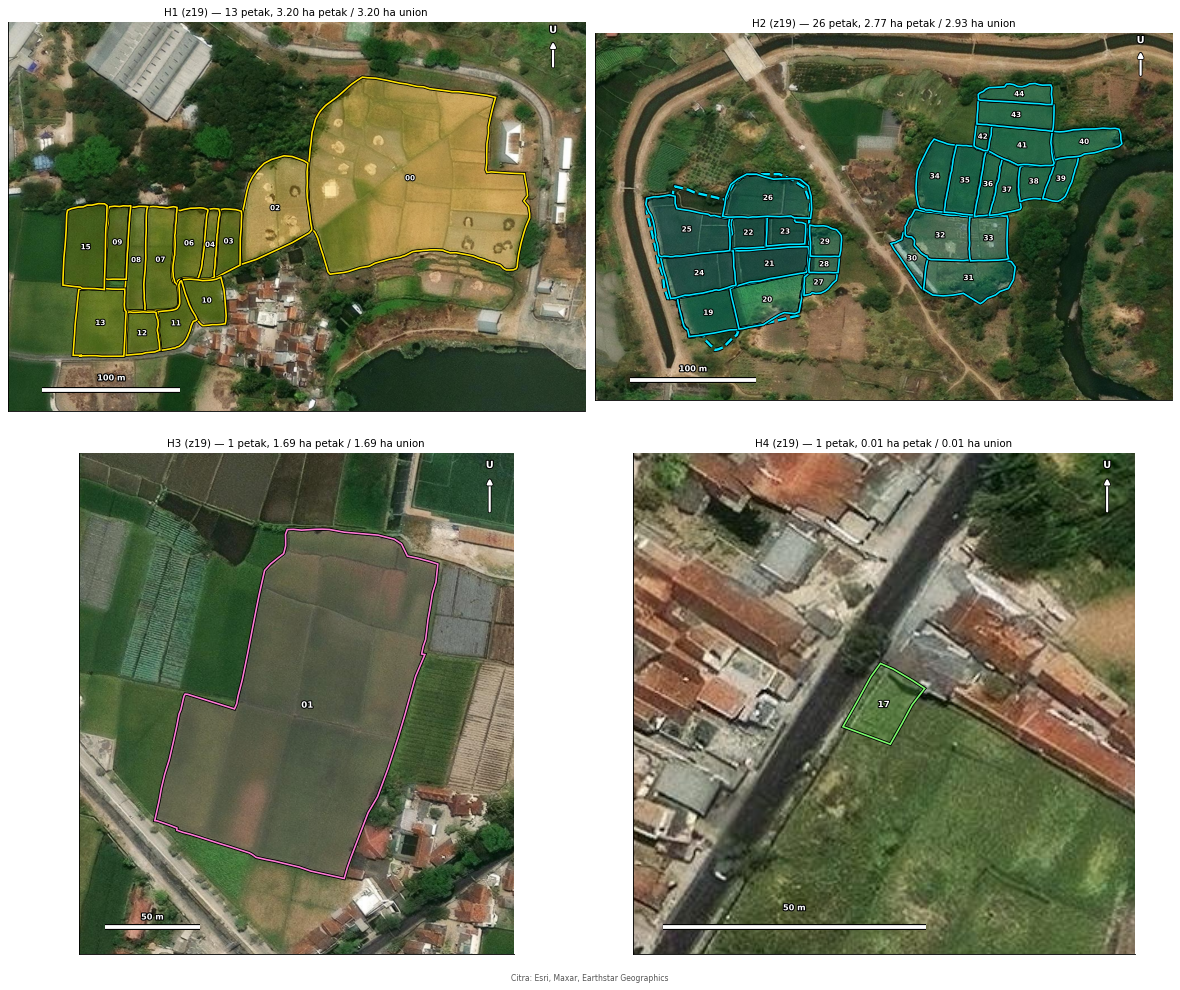

In [8]:
nham = len(HAMPARAN)
ncol = 2 if nham > 1 else 1
nrow = int(math.ceil(nham/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.6*ncol, 6.6*nrow))
axes = np.atleast_1d(axes).ravel()

for ax, (h, mem) in zip(axes, HAMPARAN.items()):
    pasang_citra(ax, h)
    gambar_poligon(ax, mem, isi=0.16, lw_petak=1.5, label_petak=True,
                   fs=6.6 if len(mem) > 6 else 8.0)
    xs = [q[0] for n in mem for q in POLI[n]]; ys = [q[1] for n in mem for q in POLI[n]]
    pk = [n for n in mem if n in PETAK]
    lu = luas_union(mem)/1e4; lp = (luas_union(pk)/1e4) if pk else 0.0
    bentang = max(max(xs)-min(xs), max(ys)-min(ys))
    skala = 100 if bentang > 260 else 50
    zoom = CITRA[h]["zoom"] if CITRA.get(h) else "-"
    rapikan(ax, f"{h} (z{zoom}) — {len(pk)} petak, {lp:.2f} ha petak / {lu:.2f} ha union",
            (min(xs)-MARGIN_PETA, max(xs)+MARGIN_PETA),
            (min(ys)-MARGIN_PETA, max(ys)+MARGIN_PETA), skala)
for ax in axes[nham:]:
    ax.axis("off")

fig.text(0.5, 0.005, KREDIT if ADA_CITRA else "(tanpa citra satelit)",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1])
simpan_gambar(fig, "02_rinci_hamparan", dpi_tampil=78); plt.show()

---
## 7. Model elevasi (DEM)

Karena KML tidak membawa ketinggian, terrain diambil dari **Terrarium** — tile DEM global
di AWS `elevation-tiles-prod`. Setiap piksel PNG menyimpan tinggi dalam warna:

$$h\ (\text{m}) = \left(R \times 256 + G + \frac{B}{256}\right) - 32768$$

Dua hal teknis yang menentukan benar-tidaknya hasil:

- **Byte warna harus utuh.** PNG dibaca dengan Pillow (`uint8` apa adanya). Kalau dibaca
  lewat pembaca yang menormalkan warna ke rentang 0–1, nilai byte-nya berubah dan tinggi
  hasil dekode ikut salah.
- **Jarak antar piksel ≠ resolusi sumber.** Terrarium menyajikan tile sampai zoom 15
  (~4,7 m/piksel di lintang ini), tetapi datanya berasal dari SRTM/ASTER ~30 m. Grid-nya
  halus, isinya tidak. Ini diukur — dibandingkan langsung dengan zoom satu tingkat di
  bawahnya.

DEM diambil **lebih luas** dari poligon (margin 300 m) supaya perhitungan kemiringan dan
arah aliran di tepi hamparan tidak memakai piksel kosong.

In [9]:
DEM_URL = "https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png"

def ambil_tile_dem(z, x, y, timeout=35):
    f = DEM_DIR / f"terrarium_{z}_{x}_{y}.png"
    if not f.exists():
        with urllib.request.urlopen(urllib.request.Request(DEM_URL.format(z=z, x=x, y=y),
                                                           headers=UA), timeout=timeout) as r:
            f.write_bytes(r.read())
    # Pillow -> uint8 apa adanya. WAJIB, supaya byte warna tidak ternormalisasi.
    return np.asarray(Image.open(f).convert("RGB")).astype(np.float64)

def susun_dem(z, margin_m):
    """DEM yang menutupi seluruh poligon + margin. -> (Z meter, x_pusat, y_pusat, res)."""
    lo0, la1 = ke_derajat(X_ALL.min()-margin_m, Y_ALL.max()+margin_m)
    lo1, la0 = ke_derajat(X_ALL.max()+margin_m, Y_ALL.min()-margin_m)
    px0, py0 = lonlat_ke_piksel(float(lo0), float(la1), z)
    px1, py1 = lonlat_ke_piksel(float(lo1), float(la0), z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    kan = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3))
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            kan[(ty-ty0)*256:(ty-ty0+1)*256,
                (tx-tx0)*256:(tx-tx0+1)*256] = ambil_tile_dem(z, tx, ty)
    tinggi = (kan[:, :, 0]*256 + kan[:, :, 1] + kan[:, :, 2]/256) - 32768.0
    i0, i1 = int(py0 - ty0*256), int(py1 - ty0*256) + 1
    j0, j1 = int(px0 - tx0*256), int(px1 - tx0*256) + 1
    tinggi = tinggi[i0:i1, j0:j1]
    jj = np.arange(tinggi.shape[1]) + 0.5 + px0
    ii = np.arange(tinggi.shape[0]) + 0.5 + py0
    lo_c = np.array([piksel_ke_lonlat(p, py0, z)[0] for p in jj])
    la_c = np.array([piksel_ke_lonlat(px0, p, z)[1] for p in ii])
    return (tinggi, (lo_c - lon0)*M_PER_DEG_LON, (la_c - lat0)*M_PER_DEG_LAT,
            meter_per_piksel(z))

ZDEM, xs_dem, ys_dem, RES = susun_dem(ZOOM_DEM, MARGIN_DEM)
GX, GY = np.meshgrid(xs_dem, ys_dem)
EXT_DEM = [xs_dem[0]-RES/2, xs_dem[-1]+RES/2, ys_dem[-1]-RES/2, ys_dem[0]+RES/2]

print(f"DEM  : {ZDEM.shape[1]} x {ZDEM.shape[0]} piksel @ z{ZOOM_DEM}")
print(f"       jarak antar piksel {RES:.2f} m | cakupan "
      f"{ZDEM.shape[1]*RES:.0f} x {ZDEM.shape[0]*RES:.0f} m")
print(f"       tinggi {ZDEM.min():.1f} .. {ZDEM.max():.1f} m dpl")

Zk, _, _, RESk = susun_dem(ZOOM_DEM-1, MARGIN_DEM)
print(f"\nUji isi informasi (z{ZOOM_DEM} vs z{ZOOM_DEM-1}, {RESk:.2f} m/piksel):")
print(f"  rentang tinggi z{ZOOM_DEM}   : {ZDEM.max()-ZDEM.min():.2f} m")
print(f"  rentang tinggi z{ZOOM_DEM-1}   : {Zk.max()-Zk.min():.2f} m")
print(f"  selisih rentang        : {abs((ZDEM.max()-ZDEM.min())-(Zk.max()-Zk.min())):.2f} m")
print("  -> rentang praktis sama: zoom tertinggi hanya MEMPERHALUS, tidak menambah")
print("     detail. Resolusi informasi tetap di kelas sumbernya (~30 m).")

# ---------- masker: seluruh lokasi, per hamparan, per poligon ----------
MASK = {}
for n in POLI:
    MASK[n] = dalam_poligon(GX.ravel(), GY.ravel(), POLI[n]).reshape(GX.shape)
MASK_HAM = {h: np.logical_or.reduce([MASK[n] for n in mem]) for h, mem in HAMPARAN.items()}
DI_LAHAN = np.logical_or.reduce(list(MASK_HAM.values()))

print(f"\nPiksel DEM di dalam poligon : {DI_LAHAN.sum():,} "
      f"({DI_LAHAN.sum()*RES*RES/10_000:.2f} ha vs {LUAS_UNION/1e4:.2f} ha union poligon)")
print(f"Piksel SUMBER (~30 m) yang menutupi seluruh lokasi : "
      f"~{LUAS_UNION/(30*30):.0f} piksel  <- ini angka jujurnya")
print(f"Piksel SUMBER per petak (median {np.median([LUAS[n] for n in PETAK]):.0f} m2) : "
      f"~{np.median([LUAS[n] for n in PETAK])/900:.1f} piksel  <- lihat bagian 13")

DEM  : 333 x 325 piksel @ z15
       jarak antar piksel 4.74 m | cakupan 1578 x 1540 m
       tinggi 682.9 .. 713.0 m dpl

Uji isi informasi (z15 vs z14, 9.48 m/piksel):
  rentang tinggi z15   : 30.13 m
  rentang tinggi z14   : 30.06 m
  selisih rentang        : 0.07 m
  -> rentang praktis sama: zoom tertinggi hanya MEMPERHALUS, tidak menambah
     detail. Resolusi informasi tetap di kelas sumbernya (~30 m).



Piksel DEM di dalam poligon : 3,500 (7.86 ha vs 7.83 ha union poligon)
Piksel SUMBER (~30 m) yang menutupi seluruh lokasi : ~87 piksel  <- ini angka jujurnya
Piksel SUMBER per petak (median 1029 m2) : ~1.1 piksel  <- lihat bagian 13


### 7b. Cek silang: seberapa yakin angka ketinggiannya?

Satu DEM tidak bisa menilai dirinya sendiri. Beberapa titik yang tersebar di semua
hamparan ditanya ke **beberapa dataset berbeda** lewat OpenTopoData. Sebarannya memberi
gambaran ketidakpastian **tegak** — dan ketidakpastian tegak inilah yang menentukan
apakah beda tinggi antar dua titik layak dipercaya atau hanya derau.

Layanan ini dibatasi (1 permintaan/detik). Kalau gagal atau tidak ada jaringan, sel ini
melewatkan diri dan sisa notebook tetap jalan.

In [10]:
def tanya_opentopo(titik_ll, dataset, timeout=35):
    lok = "|".join(f"{la:.6f},{lo:.6f}" for lo, la in titik_ll)
    u = f"https://api.opentopodata.org/v1/{dataset}?locations={lok}"
    with urllib.request.urlopen(urllib.request.Request(u, headers=UA), timeout=timeout) as r:
        d = json.loads(r.read())
    return [x["elevation"] for x in d["results"]]

# 3 titik uji per hamparan, diambil dari titik berat petak terluas di hamparan itu
# dan dua petak lain yang paling berjauhan - supaya sebarannya mewakili, bukan menumpuk.
uji_xy, uji_ham = [], []
for h, mem in HAMPARAN.items():
    pk = sorted([n for n in mem if n in PETAK], key=lambda n: -LUAS[n])
    ambil = pk[:1] + ([pk[len(pk)//2]] if len(pk) > 2 else []) + ([pk[-1]] if len(pk) > 1 else [])
    for n in dict.fromkeys(ambil):
        uji_xy.append(pusat_poligon(POLI[n])); uji_ham.append(f"{h}/{n}")

uji_ll = [tuple(float(v) for v in ke_derajat(x, y)) for x, y in uji_xy]
print(f"{len(uji_ll)} titik uji tersebar di {len(HAMPARAN)} hamparan")

DATASET = ["srtm30m", "aster30m", "srtm90m"]
banding = {}
for ds in DATASET:
    try:
        banding[ds] = tanya_opentopo(uji_ll, ds)
        print(f"  {ds:<9} OK")
    except Exception as e:
        print(f"  {ds:<9} gagal ({type(e).__name__}) - dilewati")
    time.sleep(1.2)

def dem_di(x, y):
    j = int(np.clip(np.argmin(np.abs(xs_dem - x)), 0, ZDEM.shape[1]-1))
    i = int(np.clip(np.argmin(np.abs(ys_dem - y)), 0, ZDEM.shape[0]-1))
    return float(ZDEM[i, j])

banding["terrarium"] = [dem_di(x, y) for x, y in uji_xy]

cek = pd.DataFrame(banding)
cek.insert(0, "titik", uji_ham)
cek.insert(1, "lat", [p[1] for p in uji_ll]); cek.insert(2, "lon", [p[0] for p in uji_ll])
kolom = [c for c in cek.columns if c not in ("titik", "lat", "lon")]
cek["sebar_m"] = cek[kolom].max(axis=1) - cek[kolom].min(axis=1)

print(f"\n{'='*70}")
print("  KETIDAKPASTIAN TEGAK (perbandingan antar-dataset)")
print(f"{'='*70}")
for c in kolom:
    print(f"  {c:<11}: rata-rata {cek[c].mean():7.1f} m | "
          f"rentang antar titik uji {cek[c].max()-cek[c].min():5.1f} m")
SEBAR_TEGAK = float(cek["sebar_m"].mean())
print(f"\n  Beda antar-dataset di titik yang sama : rata-rata {SEBAR_TEGAK:.1f} m "
      f"(maks {cek['sebar_m'].max():.1f} m)")
print(f"  -> beda tinggi antar dua titik baru berarti kalau JAUH LEBIH BESAR dari")
print(f"     ~{SEBAR_TEGAK:.0f} m. Beda di bawah itu: derau, bukan lereng.")
print(f"{'='*70}")
cek.round({"lat": 6, "lon": 6, **{c: 2 for c in kolom}, "sebar_m": 2})

8 titik uji tersebar di 4 hamparan


  srtm30m   OK


  aster30m  OK


  srtm90m   OK



  KETIDAKPASTIAN TEGAK (perbandingan antar-dataset)
  srtm30m    : rata-rata   696.9 m | rentang antar titik uji  16.0 m
  aster30m   : rata-rata   694.5 m | rentang antar titik uji  19.0 m
  srtm90m    : rata-rata   697.5 m | rentang antar titik uji  15.0 m
  terrarium  : rata-rata   697.0 m | rentang antar titik uji  16.1 m

  Beda antar-dataset di titik yang sama : rata-rata 3.3 m (maks 9.0 m)
  -> beda tinggi antar dua titik baru berarti kalau JAUH LEBIH BESAR dari
     ~3 m. Beda di bawah itu: derau, bukan lereng.


,titik,lat,lon,srtm30m,aster30m,srtm90m,terrarium,sebar_m
0,H1/SWH-00,-7.187614,107.910255,701.0,692.0,700.0,700.54,9.00
1,H1/SWH-08,-7.188151,107.908455,703.0,701.0,703.0,703.50,2.50
2,H1/SWH-04,-7.188051,107.908941,702.0,701.0,703.0,702.04,2.00
3,H2/SWH-25,-7.185397,107.911912,690.0,690.0,691.0,690.11,1.00
4,H2/SWH-40,-7.184768,107.914765,688.0,686.0,689.0,688.00,3.00
5,H2/SWH-42,-7.184732,107.914037,689.0,684.0,691.0,689.29,7.00
6,H3/SWH-01,-7.181247,107.909983,698.0,699.0,699.0,698.19,1.00
7,H4/SWH-17,-7.187836,107.906267,704.0,703.0,704.0,704.07,1.07


---
## 8. Bentuk permukaan: relief, kontur, dan sebaran ketinggian

Tiga cara melihat data yang sama:

- **Hillshade** — permukaan disinari matahari semu (barat laut, 45°) supaya punggungan
  dan cekungan terlihat mata. Ini gambar tafsir, bukan data mentah.
- **Kontur** — garis tinggi tiap 2 m. Arah garis kontur = arah **melintang lereng**;
  ini yang nanti menentukan arah galengan.
- **Kurva hipsometri per hamparan** — berapa persen luas hamparan berada di bawah tinggi
  tertentu. Digambar **per hamparan**, bukan digabung, karena inilah tempat beda antar
  hamparan harus dipisahkan dari kemiringan di dalam hamparan.

Angka yang dilaporkan juga dipisah: **beda tinggi seluruh lokasi** (berguna untuk tahu
posisi relatif hamparan) dan **beda tinggi di dalam tiap hamparan** (inilah yang relevan
untuk pengairan, karena air hanya mengalir di dalam satu hamparan).

                    KETINGGIAN
  Seluruh lokasi   : 687.9 .. 705.0 m dpl  -> beda 17.1 m
--------------------------------------------------------------------------
  H1  :   696.8 ..   705.0 m dpl  (rata   701.0)  -> beda DI DALAM hamparan   8.2 m
  H2  :   687.9 ..   695.3 m dpl  (rata   690.1)  -> beda DI DALAM hamparan   7.4 m
  H3  :   697.0 ..   700.0 m dpl  (rata   698.5)  -> beda DI DALAM hamparan   3.0 m
  H4  :   703.9 ..   704.4 m dpl  (rata   704.2)  -> beda DI DALAM hamparan   0.5 m
--------------------------------------------------------------------------
  Beda tinggi terbesar DI DALAM satu hamparan : 8.2 m
  Beda tinggi ANTAR hamparan (tertinggi-terendah rata-rata) : 14.1 m
  -> dari 17.1 m beda tinggi seluruh lokasi, hanya 8.2 m yang ada
     DI DALAM satu hamparan. Sisanya beda tinggi antar hamparan yang letaknya
     berjauhan - dan air tidak mengalir antar hamparan yang terpisah.
  Semua beda tinggi di dalam hamparan >> ketidakpastian DEM ~3.3 m
     -> lerengnya nya

[gambar] 03_relief_kontur.png                   607 KB


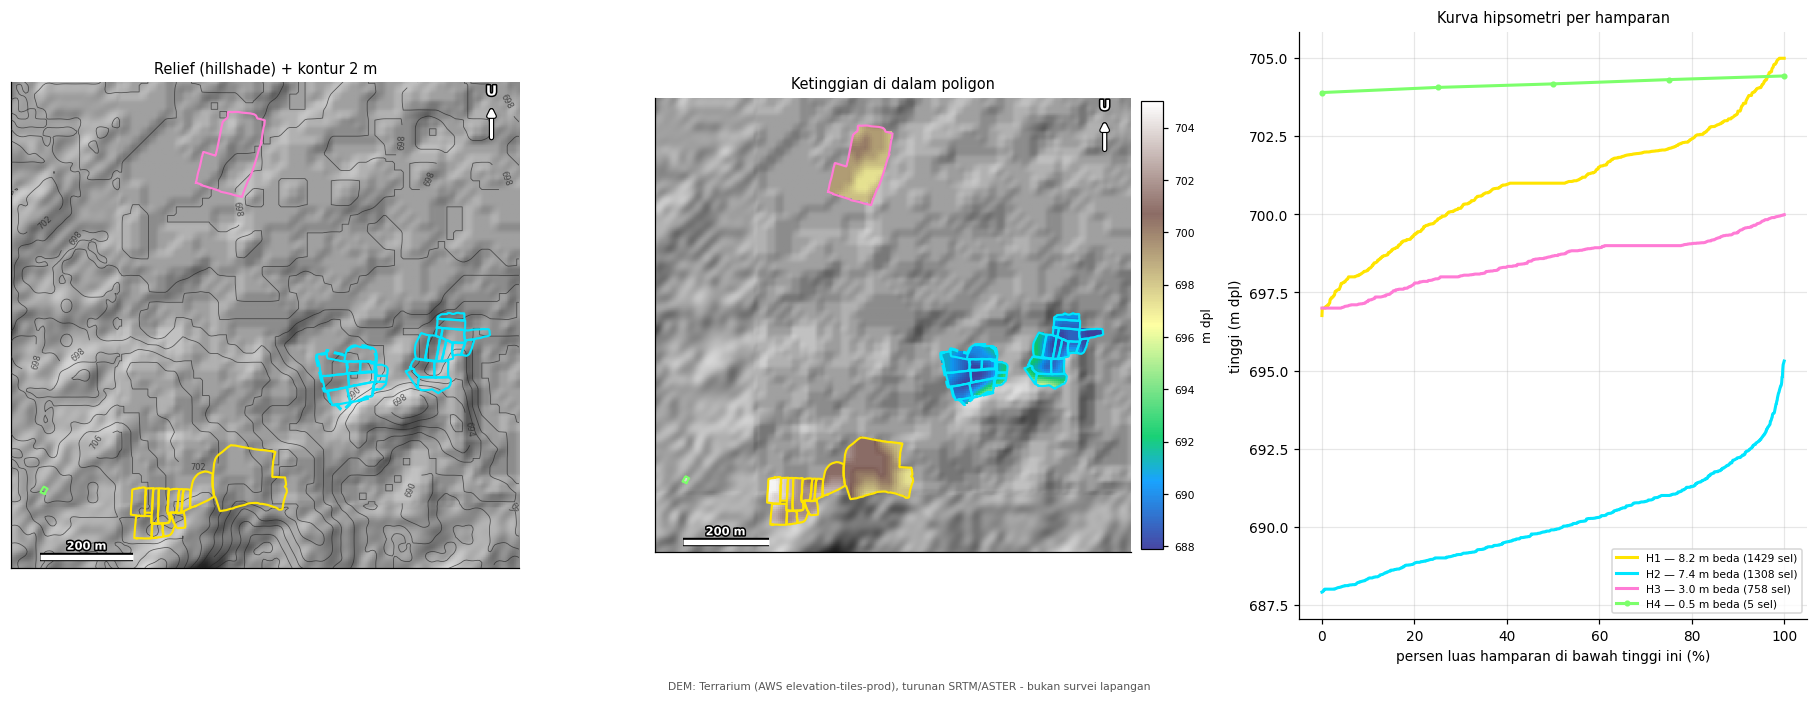

,hamparan,n_sel_dem,elev_min,elev_maks,elev_rata,beda_tinggi_m
0,H1,1429,696.76,705.00,701.01,8.24
1,H2,1308,687.91,695.30,690.12,7.40
2,H3,758,697.00,699.99,698.49,2.99
3,H4,5,703.90,704.43,704.18,0.53


In [11]:
ZL = np.where(DI_LAHAN, ZDEM, np.nan)
Z_MIN, Z_MAX = float(np.nanmin(ZL)), float(np.nanmax(ZL))
BEDA_LOKASI  = Z_MAX - Z_MIN

def gambar_batas_semua(ax, lw=1.4, hanya=None):
    for n in (hanya if hanya is not None else POLI):
        p = POLI[n] + [POLI[n][0]]
        ax.plot([q[0] for q in p], [q[1] for q in p],
                color=W_HAM[HAM_DARI[n]], lw=(2.0 if n in BLOK else lw),
                ls=("--" if n in BLOK else "-"), zorder=6)

def peta_terrain(ax, judul, data=None, cmap="terrain", satuan="", vmin=None, vmax=None,
                 hillshade=True, kontur=True, batas=True, skala_kiri=True, mg=None):
    mg = MARGIN_PETA*1.6 if mg is None else mg
    ls = LightSource(azdeg=315, altdeg=45)
    if hillshade:
        ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
                  cmap="gray", origin="upper", zorder=0)
    if data is not None:
        im = ax.imshow(np.where(DI_LAHAN, data, np.nan), extent=EXT_DEM, cmap=cmap,
                       origin="upper", vmin=vmin, vmax=vmax, alpha=0.90, zorder=2,
                       interpolation="nearest")
        cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02)
        cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    if kontur:
        lv = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
                       ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
        cs = ax.contour(GX, GY, ZDEM, levels=lv, colors="#222222",
                        linewidths=0.5, alpha=0.7, zorder=4)
        ax.clabel(cs, cs.levels[::2], fmt="%.0f", fontsize=5.4, inline=True)
    if batas:
        gambar_batas_semua(ax)
    ax.set_xlim(X_ALL.min()-mg, X_ALL.max()+mg)
    ax.set_ylim(Y_ALL.min()-mg, Y_ALL.max()+mg)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    batang_skala(ax, X_ALL.min() + (0 if skala_kiri else 0.72*(X_ALL.max()-X_ALL.min())),
                 Y_ALL.min()-mg*0.62, 200)
    panah_utara(ax)
    return ax

fig = plt.figure(figsize=(16.6, 6.4))
ax0 = fig.add_subplot(1, 3, 1); peta_terrain(ax0, "Relief (hillshade) + kontur 2 m")
ax1 = fig.add_subplot(1, 3, 2)
peta_terrain(ax1, "Ketinggian di dalam poligon", data=ZDEM, cmap="terrain",
             satuan="m dpl", vmin=Z_MIN, vmax=Z_MAX, kontur=False)

ax2 = fig.add_subplot(1, 3, 3)
ringkas_ham = []
for h, mem in HAMPARAN.items():
    z = ZDEM[MASK_HAM[h]]
    if z.size == 0:
        continue
    urut = np.sort(z)
    ax2.plot(np.linspace(0, 100, urut.size), urut, lw=2.0, color=W_HAM[h],
             marker="" if urut.size > 8 else "o", ms=3,
             label=f"{h} — {z.max()-z.min():.1f} m beda ({urut.size} sel)")
    ringkas_ham.append({"hamparan": h, "n_sel_dem": int(z.size),
                        "elev_min": float(z.min()), "elev_maks": float(z.max()),
                        "elev_rata": float(z.mean()), "beda_tinggi_m": float(z.max()-z.min())})
ax2.set_xlabel("persen luas hamparan di bawah tinggi ini (%)")
ax2.set_ylabel("tinggi (m dpl)")
ax2.set_title("Kurva hipsometri per hamparan", fontsize=9.5)
ax2.legend(fontsize=7); ax2.set_aspect("auto")
df_elev = pd.DataFrame(ringkas_ham)

BEDA_DALAM_MAKS = float(df_elev["beda_tinggi_m"].max())
print("=" * 74)
print("                    KETINGGIAN")
print("=" * 74)
print(f"  Seluruh lokasi   : {Z_MIN:.1f} .. {Z_MAX:.1f} m dpl  -> beda {BEDA_LOKASI:.1f} m")
print("-" * 74)
for _, r in df_elev.iterrows():
    print(f"  {r['hamparan']:<3} : {r['elev_min']:7.1f} .. {r['elev_maks']:7.1f} m dpl  "
          f"(rata {r['elev_rata']:7.1f})  -> beda DI DALAM hamparan {r['beda_tinggi_m']:5.1f} m")
print("-" * 74)
print(f"  Beda tinggi terbesar DI DALAM satu hamparan : {BEDA_DALAM_MAKS:.1f} m")
print(f"  Beda tinggi ANTAR hamparan (tertinggi-terendah rata-rata) : "
      f"{df_elev['elev_rata'].max()-df_elev['elev_rata'].min():.1f} m")
print(f"  -> dari {BEDA_LOKASI:.1f} m beda tinggi seluruh lokasi, hanya "
      f"{BEDA_DALAM_MAKS:.1f} m yang ada")
print("     DI DALAM satu hamparan. Sisanya beda tinggi antar hamparan yang letaknya")
print("     berjauhan - dan air tidak mengalir antar hamparan yang terpisah.")
print(f"  Semua beda tinggi di dalam hamparan >> ketidakpastian DEM ~{SEBAR_TEGAK:.1f} m")
print("     -> lerengnya nyata, bukan derau." if BEDA_DALAM_MAKS > 2*SEBAR_TEGAK else
      "     -> HATI-HATI: sebagian beda tinggi masih sekelas derau DEM.")
print("=" * 74)

fig.text(0.5, 0.015, "DEM: Terrarium (AWS elevation-tiles-prod), turunan SRTM/ASTER "
         "- bukan survei lapangan", ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "03_relief_kontur"); plt.show()
df_elev.round(2)

---
## 9. Kemiringan (slope)

Kemiringan dihitung dari gradien permukaan:

$$S = \arctan\sqrt{\left(\frac{\partial z}{\partial x}\right)^2 + \left(\frac{\partial z}{\partial y}\right)^2}$$

Dilaporkan dua-duanya: **derajat** (untuk klasifikasi lahan) dan **persen** (untuk
hidrolika). Dihitung pada dua skala, dan bedanya penting:

- **skala grid (~4,7 m)** — mengikuti tiap piksel; sebagian isinya interpolasi.
- **skala ~30 m** — dihaluskan dulu sampai sepadan resolusi sumber. **Angka inilah yang
  dipakai melaporkan**, karena hanya sampai situ datanya benar-benar ada.

Kelas kemiringan memakai pembagian yang lazim untuk kesesuaian lahan di Indonesia
(0–3 % datar, 3–8 % landai, 8–15 % agak curam, 15–30 % curam, >30 % sangat curam).

Luas permukaan miring juga dihitung: pada lereng, luas permukaan sebenarnya lebih besar
daripada luas peta. Faktornya $1/\cos S$.

                       KEMIRINGAN
  Skala grid (4.7 m)  : rata-rata  3.15 deg | maks 11.66 deg
  Skala 30 m (dipakai): rata-rata  2.58 deg = 4.5 % | maks  8.93 deg = 15.7 %
--------------------------------------------------------------------------
  kelas                  lokasi      H1      H2      H3      H4
  datar 0-3%              32.1%   35.4%   13.4%   58.4%    0.0%
  landai 3-8%             57.9%   61.8%   62.9%   41.6%  100.0%
  agak curam 8-15%         9.5%    2.8%   22.2%    0.0%    0.0%
  curam 15-30%             0.5%    0.0%    1.5%    0.0%    0.0%
  sangat curam >30%        0.0%    0.0%    0.0%    0.0%    0.0%
--------------------------------------------------------------------------
  kemiringan rata-rata (%)     4.5     3.8     6.3     2.8     3.4 
--------------------------------------------------------------------------
  Kelas dominan : landai 3-8% (58 % luas)
  Luas datar (peta)     :     78,331 m2 = 7.8331 ha
  Luas permukaan miring :     78,442 m2 = 7.8442 ha (+0.

[gambar] 04_kemiringan.png                      322 KB


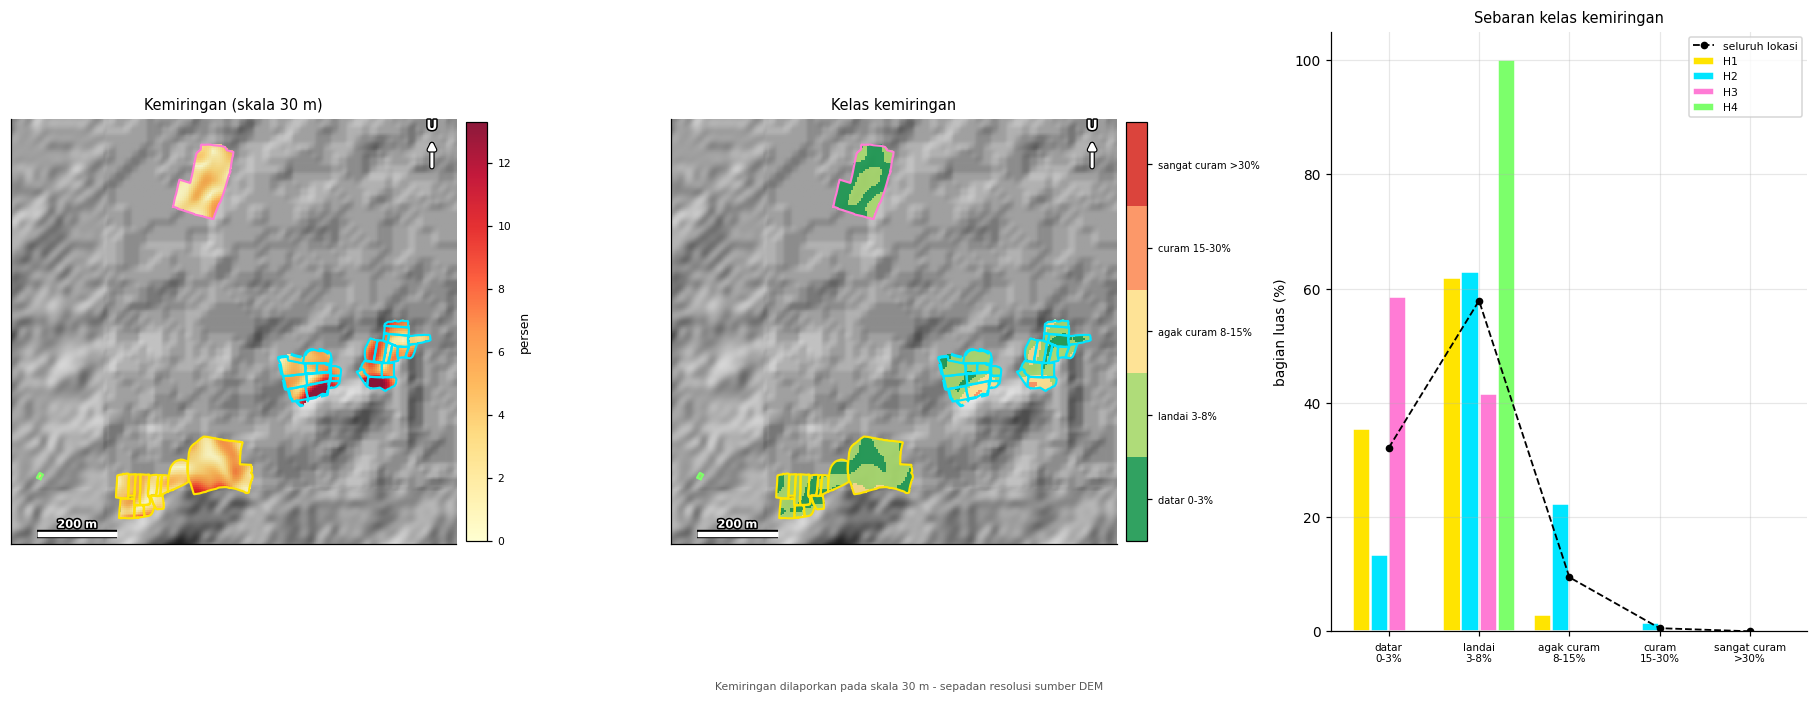

In [12]:
from scipy.ndimage import gaussian_filter

def kemiringan(Zg, res):
    dzdy, dzdx = np.gradient(Zg, res)      # baris = y (ke bawah), kolom = x
    dzdy = -dzdy                           # baris menurun ke selatan -> balik tanda
    return np.degrees(np.arctan(np.hypot(dzdx, dzdy))), dzdx, dzdy

sigma = (SLOPE_HALUS_M / RES) / 2.355      # FWHM ~ 30 m
Z_HALUS = gaussian_filter(ZDEM, sigma=sigma, mode="nearest")

SLOPE_GRID, _, _        = kemiringan(ZDEM, RES)
SLOPE_30, dzdx, dzdy    = kemiringan(Z_HALUS, RES)
SLOPE_PCT = np.tan(np.radians(SLOPE_30))*100

BATAS_KELAS = [0, 3, 8, 15, 30, 100]        # persen
NAMA_KELAS  = ["datar\n0-3%", "landai\n3-8%", "agak curam\n8-15%",
               "curam\n15-30%", "sangat curam\n>30%"]
WARNA_KELAS = ["#1a9850", "#a6d96a", "#fee08b", "#fc8d59", "#d73027"]
kelas = np.digitize(SLOPE_PCT, BATAS_KELAS[1:-1])

sl_lahan = SLOPE_30[DI_LAHAN]
SLOPE_RERATA = float(sl_lahan.mean())
SLOPE_PERSEN = math.tan(math.radians(SLOPE_RERATA))*100
FAKTOR_LERENG  = float(np.mean(1.0/np.cos(np.radians(sl_lahan))))
LUAS_PERMUKAAN = LUAS_UNION * FAKTOR_LERENG

fig, axes = plt.subplots(1, 3, figsize=(16.6, 6.4))
peta_terrain(axes[0], f"Kemiringan (skala {SLOPE_HALUS_M:.0f} m)", data=SLOPE_PCT,
             cmap="YlOrRd", satuan="persen", vmin=0, vmax=float(np.percentile(SLOPE_PCT[DI_LAHAN], 98)),
             kontur=False)

ax = axes[1]
ls = LightSource(azdeg=315, altdeg=45)
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
im = ax.imshow(np.where(DI_LAHAN, kelas, np.nan), extent=EXT_DEM, origin="upper",
               cmap=ListedColormap(WARNA_KELAS), vmin=-0.5, vmax=4.5, alpha=0.9, zorder=2,
               interpolation="nearest")
cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02, ticks=range(5))
cb.ax.set_yticklabels([n.replace("\n", " ") for n in NAMA_KELAS], fontsize=6.5)
gambar_batas_semua(ax)
mg = MARGIN_PETA*1.6
ax.set_xlim(X_ALL.min()-mg, X_ALL.max()+mg); ax.set_ylim(Y_ALL.min()-mg, Y_ALL.max()+mg)
ax.set_aspect("equal"); ax.set_title("Kelas kemiringan", fontsize=9.5)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
batang_skala(ax, X_ALL.min(), Y_ALL.min()-mg*0.62, 200); panah_utara(ax)

# sebaran kelas per hamparan
ax = axes[2]
lebar = 0.8/len(HAMPARAN)
bagi_ham = {}
for i, (h, _) in enumerate(HAMPARAN.items()):
    pct = SLOPE_PCT[MASK_HAM[h]]
    b = (pd.Series(np.digitize(pct, BATAS_KELAS[1:-1])).value_counts(normalize=True)
         .reindex(range(5)).fillna(0)*100)
    bagi_ham[h] = b.values
    ax.bar(np.arange(5) + i*lebar - 0.4 + lebar/2, b.values, width=lebar*0.95,
           color=W_HAM[h], edgecolor="white", label=h)
bagi = (pd.Series(np.digitize(np.tan(np.radians(sl_lahan))*100, BATAS_KELAS[1:-1]))
        .value_counts(normalize=True).reindex(range(5)).fillna(0)*100).values
ax.plot(range(5), bagi, "k--o", ms=4, lw=1.2, label="seluruh lokasi")
ax.set_xticks(range(5)); ax.set_xticklabels(NAMA_KELAS, fontsize=6.8)
ax.set_ylabel("bagian luas (%)"); ax.set_title("Sebaran kelas kemiringan", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

print("=" * 74)
print("                       KEMIRINGAN")
print("=" * 74)
print(f"  Skala grid ({RES:.1f} m)  : rata-rata {SLOPE_GRID[DI_LAHAN].mean():5.2f} deg | "
      f"maks {SLOPE_GRID[DI_LAHAN].max():5.2f} deg")
print(f"  Skala {SLOPE_HALUS_M:.0f} m (dipakai): rata-rata {SLOPE_RERATA:5.2f} deg = "
      f"{SLOPE_PERSEN:.1f} % | maks {sl_lahan.max():5.2f} deg = "
      f"{math.tan(math.radians(float(sl_lahan.max())))*100:.1f} %")
print("-" * 74)
print(f"  {'kelas':<20}{'lokasi':>9}" + "".join(f"{h:>8}" for h in HAMPARAN))
for i, n in enumerate(NAMA_KELAS):
    print(f"  {n.replace(chr(10), ' '):<20}{bagi[i]:>8.1f}%" +
          "".join(f"{bagi_ham[h][i]:>7.1f}%" for h in HAMPARAN))
print("-" * 74)
print(f"  {'kemiringan rata-rata (%)':<20}{SLOPE_PERSEN:>8.1f} " +
      "".join(f"{math.tan(math.radians(float(SLOPE_30[MASK_HAM[h]].mean())))*100:>7.1f} "
              for h in HAMPARAN))
print("-" * 74)
KELAS_DOMINAN = NAMA_KELAS[int(np.argmax(bagi))].replace("\n", " ")
print(f"  Kelas dominan : {KELAS_DOMINAN} ({bagi.max():.0f} % luas)")
print(f"  Luas datar (peta)     : {LUAS_UNION:>10,.0f} m2 = {LUAS_UNION/1e4:.4f} ha")
print(f"  Luas permukaan miring : {LUAS_PERMUKAAN:>10,.0f} m2 = {LUAS_PERMUKAAN/1e4:.4f} ha "
      f"(+{100*(FAKTOR_LERENG-1):.2f} %)")
print("=" * 74)

fig.text(0.5, 0.015, "Kemiringan dilaporkan pada skala 30 m - sepadan resolusi sumber DEM",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "04_kemiringan"); plt.show()

---
## 10. Arah hadap (aspect)

Aspect = ke arah mana permukaan menghadap, diukur searah jarum jam dari utara. Untuk
irigasi ini bukan hiasan:

- **arah hadap = arah air mengalir** kalau tidak ditahan;
- **satu arah hadap dominan** berarti hamparan berupa satu bidang lereng, sehingga arah
  galengan bisa seragam. Arah hadap yang **berpencar** berarti ada beberapa punggungan
  atau cekungan, dan hamparan itu harus dibagi per blok.

Tiap sel DEM luasnya sama, jadi **mencacah sel = menimbang luas** — panjang batang pada
mawar angin langsung terbaca sebagai persen luas. Hanya sel dengan kemiringan di atas 1°
yang ikut: permukaan hampir datar tidak punya arah hadap yang berarti.

Arah rata-rata dihitung sebagai **rata-rata vektor**, bukan rata-rata sudut — sudut 350°
dan 10° rata-ratanya 0°, bukan 180°. Panjang vektor hasilnya (**keterpusatan**, 0–1)
sekaligus mengukur seberapa seragam lerengnya, dan angka itu dihitung **per hamparan**
karena itulah satuan yang punya arti hidrolis.

                        ARAH HADAP LERENG
  Seluruh lokasi : 98 deg (menghadap T), keterpusatan 0.33
------------------------------------------------------------------------------
  H1  :    96 deg -> menghadap T   | keterpusatan 0.52 (BERPENCAR) | air masuk dari sisi B
  H2  :    70 deg -> menghadap T   | keterpusatan 0.16 (BERPENCAR) | air masuk dari sisi B
  H3  :   129 deg -> menghadap TG  | keterpusatan 0.36 (BERPENCAR) | air masuk dari sisi BL
  H4  :   224 deg -> menghadap BD  | keterpusatan 1.00 (SANGAT TERPUSAT - TAPI hanya 5 sel DEM, angka ini tidak berarti) | air masuk dari sisi TL
------------------------------------------------------------------------------
  Arah hadap seluruh lokasi BERPENCAR -> lokasi ini bukan satu bidang lereng.
  Wajar: hamparannya terpisah dan masing-masing punya arah sendiri, jadi satu
  angka 'arah hadap SWH-JB-GRT' tidak punya arti praktis.
  Hamparan yang arah hadapnya masih BERPENCAR: H1, H2, H3
  -> di dalamnya ada lebih dari satu bidang leren

[gambar] 05_arah_hadap.png                      448 KB


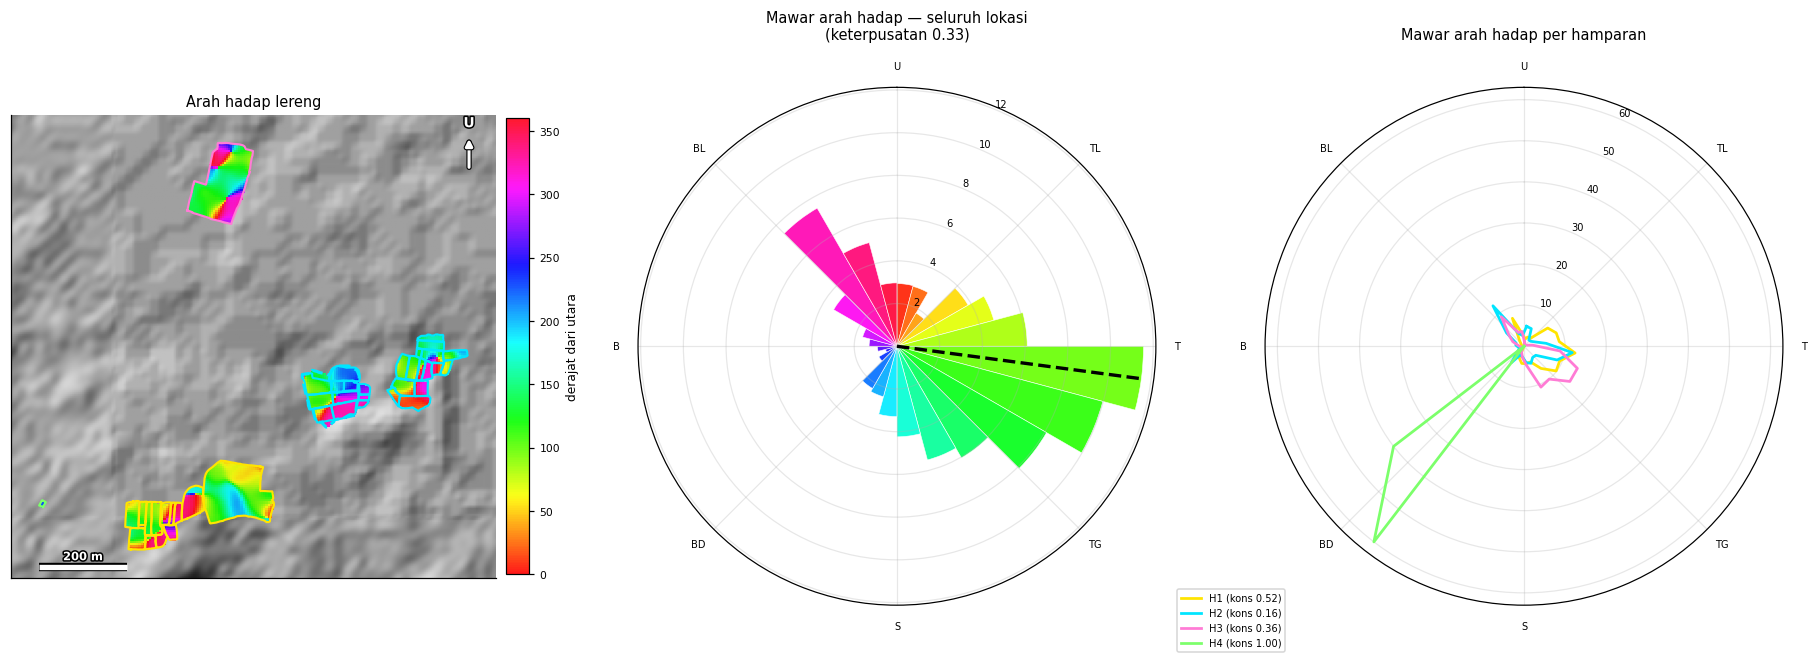

,hamparan,arah_hadap_deg,arah_hadap,keterpusatan,n_sel_berlereng,sisi_air_masuk
0,H1,95.671,T,0.522,1236,B
1,H2,69.948,T,0.160,1249,B
2,H3,129.124,TG,0.364,576,BL
3,H4,224.018,BD,0.999,5,TL


In [13]:
ASPECT = (np.degrees(np.arctan2(-dzdx, -dzdy))) % 360.0   # 0=utara, searah jarum jam
ARAH_8 = ["U", "TL", "T", "TG", "S", "BD", "B", "BL"]

def arah_rerata(mask):
    """(arah_deg, keterpusatan, n_sel) dari sel bermakna (lereng > 1 deg) di dalam mask."""
    m = mask & (SLOPE_30 > 1.0)
    a = ASPECT[m]
    if a.size == 0:
        return np.nan, np.nan, 0
    vx, vy = np.sin(np.radians(a)).mean(), np.cos(np.radians(a)).mean()
    return math.degrees(math.atan2(vx, vy)) % 360, math.hypot(vx, vy), int(a.size)

ASPEK_LOKASI, KONS_LOKASI, _ = arah_rerata(DI_LAHAN)

baris = []
for h in HAMPARAN:
    ad, kons, n = arah_rerata(MASK_HAM[h])
    baris.append({"hamparan": h, "arah_hadap_deg": ad,
                  "arah_hadap": ARAH_8[int(((ad+22.5) % 360)//45)] if np.isfinite(ad) else "-",
                  "keterpusatan": kons, "n_sel_berlereng": n,
                  "sisi_air_masuk": ARAH_8[int(((ad+180+22.5) % 360)//45)] if np.isfinite(ad) else "-"})
df_aspek = pd.DataFrame(baris)

fig = plt.figure(figsize=(16.6, 6.4))
ax0 = fig.add_subplot(1, 3, 1)
peta_terrain(ax0, "Arah hadap lereng", data=ASPECT, cmap="hsv",
             satuan="derajat dari utara", vmin=0, vmax=360, kontur=False)

ax1 = fig.add_subplot(1, 3, 2, projection="polar")
tepi = np.arange(0, 361, 15)
a_all = ASPECT[DI_LAHAN & (SLOPE_30 > 1.0)]
cacah, _ = np.histogram(a_all, bins=tepi)
cacah = cacah/cacah.sum()*100
ax1.bar(np.radians(tepi[:-1]+7.5), cacah, width=np.radians(15),
        color=plt.get_cmap("hsv")((tepi[:-1]+7.5)/360), edgecolor="white", lw=0.4, alpha=0.9)
ax1.set_theta_zero_location("N"); ax1.set_theta_direction(-1)
ax1.set_xticks(np.radians(np.arange(0, 360, 45))); ax1.set_xticklabels(ARAH_8, fontsize=8)
ax1.set_title(f"Mawar arah hadap — seluruh lokasi\n(keterpusatan {KONS_LOKASI:.2f})",
              fontsize=9.5, pad=14)
ax1.tick_params(labelsize=6.5)
ax1.plot([np.radians(ASPEK_LOKASI)]*2, [0, cacah.max()], color="black", lw=2.2, ls="--")

ax2 = fig.add_subplot(1, 3, 3, projection="polar")
for h in HAMPARAN:
    a = ASPECT[MASK_HAM[h] & (SLOPE_30 > 1.0)]
    if a.size < 4:
        continue
    c, _ = np.histogram(a, bins=tepi); c = c/c.sum()*100
    ax2.plot(np.radians(np.append(tepi[:-1]+7.5, tepi[0]+7.5)), np.append(c, c[0]),
             lw=1.8, color=W_HAM[h], label=f"{h} (kons {arah_rerata(MASK_HAM[h])[1]:.2f})")
ax2.set_theta_zero_location("N"); ax2.set_theta_direction(-1)
ax2.set_xticks(np.radians(np.arange(0, 360, 45))); ax2.set_xticklabels(ARAH_8, fontsize=8)
ax2.set_title("Mawar arah hadap per hamparan", fontsize=9.5, pad=14)
ax2.tick_params(labelsize=6.5)
ax2.legend(fontsize=6.5, loc="lower left", bbox_to_anchor=(-0.18, -0.10))

print("=" * 78)
print("                        ARAH HADAP LERENG")
print("=" * 78)
print(f"  Seluruh lokasi : {ASPEK_LOKASI:.0f} deg (menghadap "
      f"{ARAH_8[int(((ASPEK_LOKASI+22.5) % 360)//45)]}), keterpusatan {KONS_LOKASI:.2f}")
print("-" * 78)
for _, r in df_aspek.iterrows():
    ket = ("SANGAT TERPUSAT" if r["keterpusatan"] > 0.85 else
           "cukup terpusat" if r["keterpusatan"] > 0.60 else
           "BERPENCAR")
    if r["n_sel_berlereng"] < 20:
        ket += f" - TAPI hanya {r['n_sel_berlereng']} sel DEM, angka ini tidak berarti"
    print(f"  {r['hamparan']:<3} : {r['arah_hadap_deg']:5.0f} deg -> menghadap "
          f"{r['arah_hadap']:<3} | keterpusatan {r['keterpusatan']:.2f} ({ket})"
          f" | air masuk dari sisi {r['sisi_air_masuk']}")
print("-" * 78)
if KONS_LOKASI < 0.6:
    print("  Arah hadap seluruh lokasi BERPENCAR -> lokasi ini bukan satu bidang lereng.")
    print("  Wajar: hamparannya terpisah dan masing-masing punya arah sendiri, jadi satu")
    print("  angka 'arah hadap SWH-JB-GRT' tidak punya arti praktis.")
berpencar = df_aspek[df_aspek["keterpusatan"] < 0.6]["hamparan"].tolist()
if berpencar:
    print(f"  Hamparan yang arah hadapnya masih BERPENCAR: {', '.join(berpencar)}")
    print("  -> di dalamnya ada lebih dari satu bidang lereng (cekungan/punggungan).")
    print("     Satu arah galengan tidak cukup; hamparan itu perlu dibagi per blok, dan")
    print("     letak pembaginya harus dipastikan di lapangan - DEM 30 m tidak cukup")
    print("     halus untuk menariknya.")
print("=" * 78)

plt.tight_layout()
simpan_gambar(fig, "05_arah_hadap"); plt.show()
df_aspek.round(3)

---
## 11. Ke mana air mengalir

Tiga langkah baku analisis aliran permukaan:

1. **Isi cekungan** (*priority flood*). DEM selalu punya cekungan palsu akibat derau;
   kalau dibiarkan, jalur aliran putus di tengah jalan. Pengisian dilakukan **dua kali**:
   sekali apa adanya untuk *mengukur* kedalaman cekungan, sekali lagi dengan kemiringan
   buatan 0,1 mm per sel untuk *menelusuri* aliran — tanpa itu bekas cekungan menjadi
   bidang datar sempurna dan penelusuran berhenti di situ.
2. **Arah aliran D8.** Tiap sel mengalirkan air ke satu dari 8 tetangga dengan penurunan
   per jarak terbesar.
3. **Akumulasi aliran.** Berapa banyak sel yang bermuara lewat tiap sel — nilai besar
   menandai **alur alami**, tempat air berkumpul saat hujan.

Yang dicari: **dari sisi mana air masuk dan keluar tiap hamparan**, dan **di mana alur
alaminya** — karena melawan alur alami adalah cara termahal membangun saluran.

> Pada DEM ~30 m, alur yang muncul adalah alur **skala bentang lahan**, bukan parit kecil
> di dalam petak. Dipakai untuk arah umum, bukan menempatkan saluran.
>
> **Garis-garis sejajar miring pada peta akumulasi adalah cacat metode D8, bukan bentang
> alam.** Karena tiap sel hanya boleh memilih satu dari delapan arah, aliran di lereng
> yang halus "dibulatkan" ke arah terdekat lalu menumpuk menjadi jalur lurus berulang.
> Yang boleh dibaca hanya **alur utama yang tebal dan menerus**.

Cekungan terisi : 15,649 sel (14.5 % grid), terdalam 4.10 m
Sel buntu di dalam poligon : 0 -> aman
Akumulasi maks di dalam poligon : 37,108 sel = 83.37 ha daerah tangkapan

            TITIK KELUAR DAN TINGGI TERJUN PER HAMPARAN
  H1  :  696.8 ..  705.0 m dpl -> terjun  8.2 m | air masuk sisi B   keluar sisi T  
        titik keluar di 696.8 m dpl, daerah tangkapan 6.94 ha
  H2  :  687.9 ..  695.3 m dpl -> terjun  7.4 m | air masuk sisi B   keluar sisi T  
        titik keluar di 688.0 m dpl, daerah tangkapan 83.37 ha
        CATATAN: tangkapan 83.37 ha jauh lebih luas daripada hamparannya sendiri
        (2.93 ha) -> hamparan ini MENERIMA aliran dari luar.
        Saat hujan lebat, air dari atas lewat di sini: perlu saluran
        pengelak, bukan hanya saluran pembuang petak.
  H3  :  697.0 ..  700.0 m dpl -> terjun  3.0 m | air masuk sisi BL  keluar sisi TG 
        titik keluar di 698.0 m dpl, daerah tangkapan 8.75 ha
        CATATAN: tangkapan 8.75 ha jauh lebih luas daripada hamp

[gambar] 06_arah_aliran.png                   1,116 KB


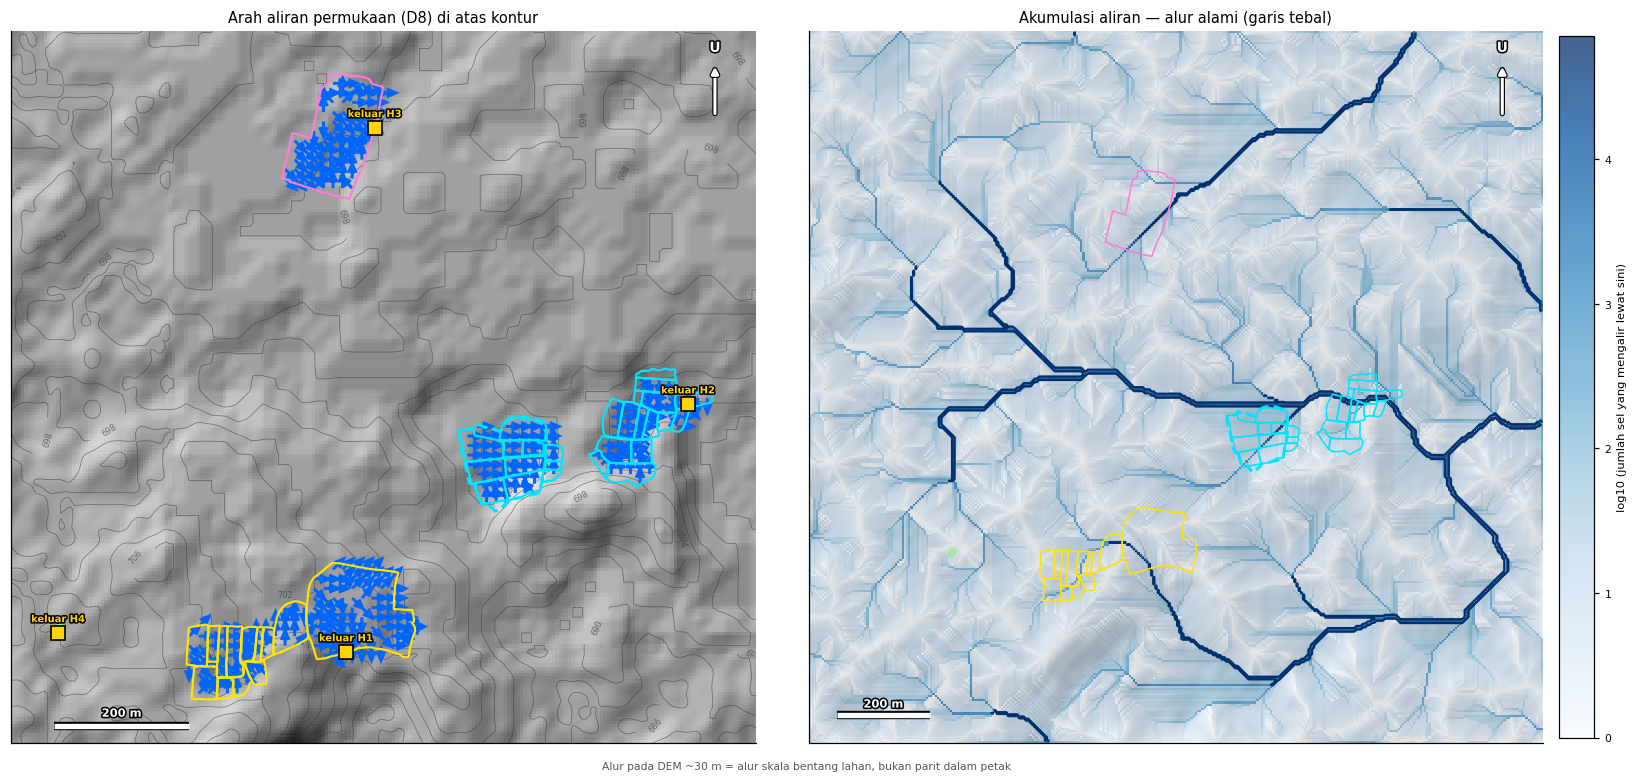

,hamparan,elev_tertinggi,elev_terendah,terjun_m,x_keluar_m,y_keluar_m,elev_keluar_m,tangkapan_keluar_ha
0,H1,705.00,696.76,8.24,-160.66,-215.86,696.76,6.94
1,H2,695.30,687.91,7.40,346.52,151.43,687.99,83.37
2,H3,699.99,697.00,2.99,-118.00,561.10,698.00,8.75
3,H4,704.43,703.90,0.53,-587.26,-187.60,703.90,0.01


In [14]:
def isi_cekungan(Zg, eps=0.0):
    """Priority flood: isi cekungan supaya tiap sel punya jalan keluar.

    `eps` > 0 memberi kemiringan buatan sangat kecil pada bagian yang terisi, supaya
    tidak tersisa bidang datar sempurna - di bidang datar D8 tidak menemukan tetangga
    yang lebih rendah dan penelusuran BERHENTI sebelum sampai titik keluar.
    """
    ny, nx = Zg.shape
    keluar = np.full(Zg.shape, np.inf)
    sudah  = np.zeros(Zg.shape, bool)
    antre  = []
    for i in range(ny):
        for j in (0, nx-1):
            heapq.heappush(antre, (Zg[i, j], i, j)); sudah[i, j] = True
    for j in range(nx):
        for i in (0, ny-1):
            if not sudah[i, j]:
                heapq.heappush(antre, (Zg[i, j], i, j)); sudah[i, j] = True
    while antre:
        z, i, j = heapq.heappop(antre)
        keluar[i, j] = z
        for di, dj in ((-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)):
            ii, jj = i+di, j+dj
            if 0 <= ii < ny and 0 <= jj < nx and not sudah[ii, jj]:
                sudah[ii, jj] = True
                heapq.heappush(antre, (max(Zg[ii, jj], z + eps), ii, jj))
    return keluar

Z_ISI  = isi_cekungan(Z_HALUS)                 # untuk MENGUKUR kedalaman cekungan
TERISI = Z_ISI - Z_HALUS
Z_D8   = isi_cekungan(Z_HALUS, eps=1e-4)       # untuk MENELUSURI arah aliran

ARAH = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]   # U, TL, T, TG, S, BD, B, BL
ny, nx = Z_ISI.shape

def arah_d8(Zg, res):
    ke = np.full(Zg.shape, -1, int)
    for i in range(ny):
        for j in range(nx):
            terbaik, arah = 0.0, -1
            for k, (di, dj) in enumerate(ARAH):
                ii, jj = i+di, j+dj
                if not (0 <= ii < ny and 0 <= jj < nx):
                    continue
                turun = (Zg[i, j] - Zg[ii, jj]) / (res*math.hypot(di, dj))
                if turun > terbaik:
                    terbaik, arah = turun, k
            ke[i, j] = arah
    return ke

D8 = arah_d8(Z_D8, RES)
buntu = int(((D8 < 0) & DI_LAHAN).sum())

def akumulasi(ke, Zg):
    """Jumlah sel yang mengalir lewat tiap sel (diproses dari tinggi ke rendah)."""
    akum = np.ones(Zg.shape, float)
    for idx in np.argsort(Zg.ravel())[::-1]:
        i, j = divmod(int(idx), nx)
        k = ke[i, j]
        if k >= 0:
            di, dj = ARAH[k]
            akum[i+di, j+dj] += akum[i, j]
    return akum

AKUM = akumulasi(D8, Z_D8)
LUAS_ALIRAN = AKUM * RES * RES        # m2 daerah tangkapan tiap sel

print(f"Cekungan terisi : {(TERISI > 0.01).sum():,} sel "
      f"({100*(TERISI>0.01).sum()/TERISI.size:.1f} % grid), terdalam {TERISI.max():.2f} m")
print(f"Sel buntu di dalam poligon : {buntu} "
      f"-> {'aman' if buntu == 0 else 'PERIKSA: jalur aliran bisa terputus'}")
print(f"Akumulasi maks di dalam poligon : {AKUM[DI_LAHAN].max():,.0f} sel "
      f"= {LUAS_ALIRAN[DI_LAHAN].max()/10_000:.2f} ha daerah tangkapan\n")

# ---------- titik keluar per hamparan ----------
baris = []
for h, mem in HAMPARAN.items():
    m = MASK_HAM[h]
    idx_out = np.unravel_index(np.argmax(np.where(m, AKUM, -np.inf)), AKUM.shape)
    idx_hi  = np.unravel_index(np.argmax(np.where(m, ZDEM, -np.inf)), ZDEM.shape)
    idx_lo  = np.unravel_index(np.argmin(np.where(m, ZDEM,  np.inf)), ZDEM.shape)
    baris.append({"hamparan": h,
                  "elev_tertinggi": float(ZDEM[idx_hi]), "elev_terendah": float(ZDEM[idx_lo]),
                  "terjun_m": float(ZDEM[idx_hi]-ZDEM[idx_lo]),
                  "x_keluar_m": float(GX[idx_out]), "y_keluar_m": float(GY[idx_out]),
                  "elev_keluar_m": float(ZDEM[idx_out]),
                  "tangkapan_keluar_ha": float(LUAS_ALIRAN[idx_out]/1e4),
                  "_hi": idx_hi, "_lo": idx_lo, "_out": idx_out})
df_alir = pd.DataFrame(baris)

fig, axes = plt.subplots(1, 2, figsize=(15.2, 7.0))

ax = axes[0]
ls = LightSource(azdeg=315, altdeg=45)
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
lv = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
               ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
cs = ax.contour(GX, GY, ZDEM, levels=lv, colors="#333333", linewidths=0.45, alpha=0.6, zorder=2)
ax.clabel(cs, cs.levels[::2], fmt="%.0f", fontsize=5.4, inline=True)
lom = max(1, int(round(14.0/RES)))          # panah tiap ~14 m
sx = np.array([[ARAH[k][1] if k >= 0 else 0 for k in b] for b in D8], float)
sy = np.array([[-ARAH[k][0] if k >= 0 else 0 for k in b] for b in D8], float)
pjg = np.hypot(sx, sy); pjg[pjg == 0] = 1
mp = DI_LAHAN[::lom, ::lom]
ax.quiver(GX[::lom, ::lom][mp], GY[::lom, ::lom][mp],
          (sx/pjg)[::lom, ::lom][mp], (sy/pjg)[::lom, ::lom][mp],
          color="#0066ff", scale=40, width=0.004, zorder=5, headwidth=3.6, headlength=4.2)
gambar_batas_semua(ax)
for _, r in df_alir.iterrows():
    ax.plot(r["x_keluar_m"], r["y_keluar_m"], marker="s", ms=9, mfc="#ffd400",
            mec="black", mew=1.1, zorder=8)
    ax.text(r["x_keluar_m"], r["y_keluar_m"]+16, f"keluar {r['hamparan']}", fontsize=6.5,
            color="#ffd400", ha="center", weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
mg = MARGIN_PETA*1.6
ax.set_xlim(X_ALL.min()-mg, X_ALL.max()+mg); ax.set_ylim(Y_ALL.min()-mg, Y_ALL.max()+mg)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Arah aliran permukaan (D8) di atas kontur", fontsize=9.5)
batang_skala(ax, X_ALL.min(), Y_ALL.min()-mg*0.62, 200); panah_utara(ax)

ax = axes[1]
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
im = ax.imshow(np.log10(AKUM), extent=EXT_DEM, origin="upper", cmap="Blues",
               alpha=0.75, zorder=2, interpolation="nearest")
cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02)
cb.set_label("log10 (jumlah sel yang mengalir lewat sini)", fontsize=7.5)
cb.ax.tick_params(labelsize=7)
ax.contour(GX, GY, AKUM, levels=[np.percentile(AKUM, 99.0)], colors="#00306e",
           linewidths=1.5, zorder=4)
gambar_batas_semua(ax, lw=1.0)
ax.set_xlim(EXT_DEM[0], EXT_DEM[1]); ax.set_ylim(EXT_DEM[2], EXT_DEM[3])
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Akumulasi aliran — alur alami (garis tebal)", fontsize=9.5)
batang_skala(ax, EXT_DEM[0]+60, EXT_DEM[2]+60, 200); panah_utara(ax)

print("=" * 78)
print("            TITIK KELUAR DAN TINGGI TERJUN PER HAMPARAN")
print("=" * 78)
for _, r in df_alir.iterrows():
    a = df_aspek.set_index("hamparan").loc[r["hamparan"]]
    print(f"  {r['hamparan']:<3} : {r['elev_terendah']:6.1f} .. {r['elev_tertinggi']:6.1f} m dpl "
          f"-> terjun {r['terjun_m']:4.1f} m | air masuk sisi {a['sisi_air_masuk']:<3} "
          f"keluar sisi {a['arah_hadap']:<3}")
    print(f"        titik keluar di {r['elev_keluar_m']:.1f} m dpl, "
          f"daerah tangkapan {r['tangkapan_keluar_ha']:.2f} ha")
    if r["tangkapan_keluar_ha"] > 3*luas_union(HAMPARAN[r["hamparan"]])/1e4:
        print(f"        CATATAN: tangkapan {r['tangkapan_keluar_ha']:.2f} ha jauh lebih luas "
              f"daripada hamparannya sendiri")
        print(f"        ({luas_union(HAMPARAN[r['hamparan']])/1e4:.2f} ha) -> hamparan ini "
              f"MENERIMA aliran dari luar.")
        print("        Saat hujan lebat, air dari atas lewat di sini: perlu saluran")
        print("        pengelak, bukan hanya saluran pembuang petak.")
print("=" * 78)
print(f"  Semua tinggi terjun di atas berada di kisaran {df_alir['terjun_m'].min():.1f}-"
      f"{df_alir['terjun_m'].max():.1f} m, sedangkan ketidakpastian tegak DEM "
      f"~{SEBAR_TEGAK:.1f} m.")
print("  -> arah masuk/keluar boleh dipakai; ANGKA terjunnya harus diukur lapangan")
print("     sebelum dipakai mendesain bangunan.")
print("=" * 78)

fig.text(0.5, 0.015, "Alur pada DEM ~30 m = alur skala bentang lahan, bukan parit dalam petak",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "06_arah_aliran"); plt.show()
df_alir.drop(columns=["_hi", "_lo", "_out"]).round(2)

---
## 12. Potongan melintang tiap hamparan

Peta menunjukkan sebaran; **potongan** menunjukkan bentuknya. Untuk tiap hamparan dibuat
dua irisan lewat titik beratnya:

- **A-A' searah lereng** (mengikuti arah hadap rata-rata hamparan itu) — memperlihatkan
  seberapa panjang dan seberapa terus-menerus turunannya.
- **B-B' searah kontur** (tegak lurus arah lereng) — idealnya mendatar. Kalau irisan ini
  ikut miring, permukaannya **memuntir**: satu garis galengan lurus tidak akan mendatar
  di kedua ujungnya.

Nisbah tegak (*vertical exaggeration*) dicantumkan supaya lereng tidak terbaca lebih
dramatis daripada aslinya.

                      POTONGAN MELINTANG
  H1  A-A' searah lereng :   6.4 m ->   3.0 %
      B-B' searah kontur :   1.7 m ->   2.1 %  -> puntiran ~35 deg
      beda melintang (1.7 m) masih di bawah ketidakpastian DEM (~3.3 m)
      -> hamparan ini boleh dianggap satu bidang lereng seragam.
  H2  A-A' searah lereng :   4.7 m ->   1.2 %
      B-B' searah kontur :   2.4 m ->   5.0 %  -> puntiran ~76 deg
      beda melintang (2.4 m) masih di bawah ketidakpastian DEM (~3.3 m)
      -> hamparan ini boleh dianggap satu bidang lereng seragam.
  H3  A-A' searah lereng :   2.5 m ->   2.6 %
      B-B' searah kontur :   0.7 m ->   0.4 %  -> puntiran ~9 deg
      beda melintang (0.7 m) masih di bawah ketidakpastian DEM (~3.3 m)
      -> hamparan ini boleh dianggap satu bidang lereng seragam.
------------------------------------------------------------------------------
  Titik-titik pada grafik itu sel DEM: pada hamparan sesempit ini jumlahnya
  sedikit, jadi bentuk potongan adalah GARIS BESAR, buk

[gambar] 07_potongan_melintang.png              234 KB


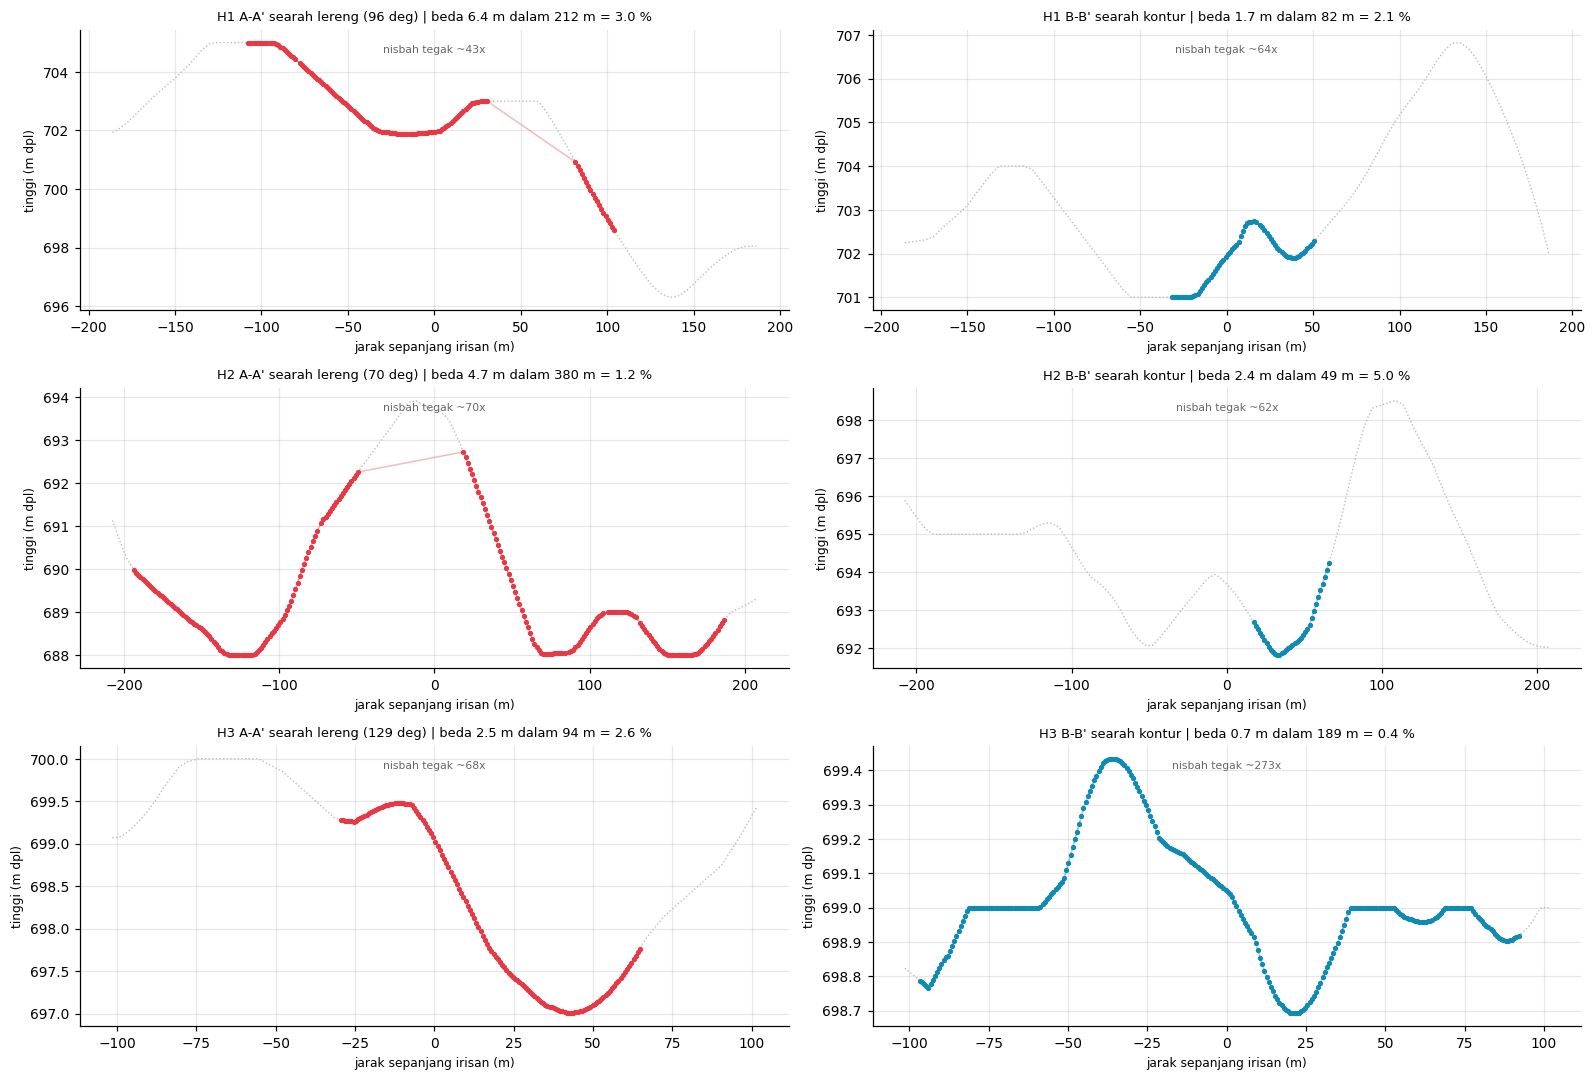

,hamparan,arah_deg,lereng_searah_persen,beda_searah_m,lereng_melintang_persen,beda_melintang_m,puntiran_deg
0,H1,95.67,3.02,6.40,2.12,1.74,35.04
1,H2,69.95,1.24,4.72,5.02,2.44,76.09
2,H3,129.12,2.62,2.47,0.39,0.74,8.54


In [15]:
def sampel_dem(Zg, xq, yq):
    """Ambil nilai DEM di titik sembarang (bilinear)."""
    fx = (np.asarray(xq, float) - xs_dem[0]) / RES
    fy = (ys_dem[0] - np.asarray(yq, float)) / RES        # ys_dem menurun
    fx = np.clip(fx, 0, Zg.shape[1]-1.001); fy = np.clip(fy, 0, Zg.shape[0]-1.001)
    j0, i0 = fx.astype(int), fy.astype(int)
    tx, ty = fx-j0, fy-i0
    return ((Zg[i0, j0]*(1-tx) + Zg[i0, j0+1]*tx)*(1-ty) +
            (Zg[i0+1, j0]*(1-tx) + Zg[i0+1, j0+1]*tx)*ty)

def potong(cx, cy, sudut_deg, panjang, mem, n=300):
    ux, uy = math.sin(math.radians(sudut_deg)), math.cos(math.radians(sudut_deg))
    s = np.linspace(-panjang/2, panjang/2, n)
    xq, yq = cx + s*ux, cy + s*uy
    z = sampel_dem(ZDEM, xq, yq)
    di = np.zeros(xq.shape, bool)
    for nm in mem:
        di |= dalam_poligon(xq, yq, POLI[nm])
    return s, z, di, xq, yq

ham_pakai = [h for h in HAMPARAN
             if MASK_HAM[h].sum() >= 20 and np.isfinite(
                 df_aspek.set_index("hamparan").loc[h, "arah_hadap_deg"])]
fig, axes = plt.subplots(len(ham_pakai), 2, figsize=(14.6, 3.3*len(ham_pakai)),
                         squeeze=False)
baris = []
for r, h in enumerate(ham_pakai):
    mem = HAMPARAN[h]
    xs = [q[0] for n in mem for q in POLI[n]]; ys = [q[1] for n in mem for q in POLI[n]]
    cx, cy = float(np.mean(xs)), float(np.mean(ys))
    L = 1.1*max(max(xs)-min(xs), max(ys)-min(ys))
    ad = float(df_aspek.set_index("hamparan").loc[h, "arah_hadap_deg"])
    hasil = {}
    for k, (sud, warna, tanda, judul) in enumerate(
            ((ad, "#e63946", "A", f"searah lereng ({ad:.0f} deg)"),
             ((ad+90) % 360, "#118ab2", "B", "searah kontur"))):
        s, z, di, xq, yq = potong(cx, cy, sud, L, mem)
        ax = axes[r][k]
        ax.plot(s, z, color="#bbb", lw=0.9, ls=":", zorder=2)
        if di.sum() >= 2:
            ax.plot(s[di], z[di], color=warna, lw=1.0, alpha=0.35, zorder=3)
            ax.scatter(s[di], z[di], s=6, color=warna, zorder=4)
            dz = float(z[di].max()-z[di].min()); ds = float(s[di].max()-s[di].min())
        else:
            dz = ds = 0.0
        lr = 100*dz/ds if ds else 0.0
        hasil[tanda] = (dz, ds, lr)
        ax.set_title(f"{h} {tanda}-{tanda}' {judul} | beda {dz:.1f} m dalam {ds:.0f} m "
                     f"= {lr:.1f} %", fontsize=8.5)
        ax.set_xlabel("jarak sepanjang irisan (m)", fontsize=8)
        ax.set_ylabel("tinggi (m dpl)", fontsize=8); ax.set_aspect("auto")
        ve = ((ax.get_xlim()[1]-ax.get_xlim()[0]) /
              max(ax.get_ylim()[1]-ax.get_ylim()[0], 1e-9))
        ax.text(0.5, 0.92, f"nisbah tegak ~{ve:.0f}x", transform=ax.transAxes,
                ha="center", fontsize=7, color="#666")
    pun = math.degrees(math.atan2(hasil["B"][2], hasil["A"][2])) if hasil["A"][2] > 0 else 0.0
    baris.append({"hamparan": h, "arah_deg": ad,
                  "lereng_searah_persen": hasil["A"][2], "beda_searah_m": hasil["A"][0],
                  "lereng_melintang_persen": hasil["B"][2], "beda_melintang_m": hasil["B"][0],
                  "puntiran_deg": pun})
df_potong = pd.DataFrame(baris)

print("=" * 78)
print("                      POTONGAN MELINTANG")
print("=" * 78)
for _, r in df_potong.iterrows():
    print(f"  {r['hamparan']:<3} A-A' searah lereng : {r['beda_searah_m']:5.1f} m -> "
          f"{r['lereng_searah_persen']:5.1f} %")
    print(f"      B-B' searah kontur : {r['beda_melintang_m']:5.1f} m -> "
          f"{r['lereng_melintang_persen']:5.1f} %  -> puntiran ~{r['puntiran_deg']:.0f} deg")
    if r["beda_melintang_m"] < SEBAR_TEGAK:
        print(f"      beda melintang ({r['beda_melintang_m']:.1f} m) masih di bawah "
              f"ketidakpastian DEM (~{SEBAR_TEGAK:.1f} m)")
        print("      -> hamparan ini boleh dianggap satu bidang lereng seragam.")
    elif r["puntiran_deg"] < 15:
        print("      puntiran kecil -> galengan lurus searah kontur masih dapat dipakai,")
        print("      asalkan elevasi kedua ujungnya dikoreksi saat pelaksanaan.")
    else:
        print("      permukaan MEMUNTIR -> galengan harus mengikuti garis kontur,")
        print("      bukan garis lurus.")
print("-" * 78)
print("  Titik-titik pada grafik itu sel DEM: pada hamparan sesempit ini jumlahnya")
print("  sedikit, jadi bentuk potongan adalah GARIS BESAR, bukan profil rinci.")
bentrok = [r["hamparan"] for _, r in df_potong.iterrows()
           if r["beda_melintang_m"] < SEBAR_TEGAK
           and float(df_aspek.set_index("hamparan").loc[r["hamparan"], "keterpusatan"]) < 0.6]
if bentrok:
    print("-" * 78)
    print(f"  PERHATIAN - hasil di sini BERTENTANGAN dengan bagian 10 untuk "
          f"{', '.join(bentrok)}:")
    print("  potongan bilang 'boleh dianggap satu bidang lereng', arah hadap bilang")
    print("  'berpencar'. Yang menang arah hadap. Alasannya: potongan hanya menyusuri")
    print("  SATU garis lewat titik tengah, sedangkan arah hadap menimbang SEMUA sel.")
    print("  Jadi yang dibuktikan potongan cuma: sepanjang garis itu bedanya di bawah")
    print("  derau DEM - bukan bahwa seluruh hamparan satu bidang.")
print("=" * 78)

plt.tight_layout()
simpan_gambar(fig, "07_potongan_melintang"); plt.show()
df_potong.round(2)

---
## 13. Terrain per petak — dan seberapa jauh boleh dipercaya

Inilah tabel yang dipakai sehari-hari: satu baris per petak, berisi luas, ketinggian,
kemiringan, dan arah hadap.

Sebelum dibaca, satu hal harus jelas dulu. Resolusi **sumber** DEM ~30 m, artinya satu
piksel sumber menutupi ~900 m² — kira-kira **seukuran satu petak di sini**. Jadi kolom
`piksel_sumber` di bawah bukan hiasan: kalau nilainya sekitar 1, angka kemiringan dan
arah hadap petak itu berasal dari **satu** pengukuran sumber yang diinterpolasi, bukan
dari pengamatan bentuk permukaan petak tersebut.

Cara membacanya:

| `piksel_sumber` | Arti | Boleh dipakai untuk |
|---|---|---|
| < 1 | petak lebih kecil dari satu piksel sumber | hanya **posisi relatif** (di hulu atau di hilir) |
| 1 – 3 | petak seukuran beberapa piksel | urutan kasar tinggi antar petak |
| > 3 | petak cukup besar | kemiringan petak, dengan hati-hati |

Luas tetap boleh dipercaya penuh — luas datang dari poligon KML, bukan dari DEM.

           SEBERAPA JAUH TERRAIN PER PETAK BOLEH DIPERCAYA
  Satu piksel sumber DEM (~30 m) = 900 m2 = 0.090 ha
  Luas petak: median 1,029 m2 (1.1 piksel sumber)
    posisi saja             : 19 petak (  46 %)
    urutan kasar            : 19 petak (  46 %)
    kemiringan (hati-hati)  :  3 petak (   7 %)
------------------------------------------------------------------------------
  Kesimpulan jujurnya: pada berkas ini terrain PER PETAK tidak bisa dipakai
  merancang apa pun. Yang dapat dipakai adalah terrain PER HAMPARAN (bagian 8-12)
  ditambah POSISI RELATIF petak (hulu/hilir) dari kolom elev_rata_m.
  Untuk desain per petak, satu-satunya jalan adalah pengukuran lapangan.


[gambar] 08_terrain_per_petak.png               147 KB


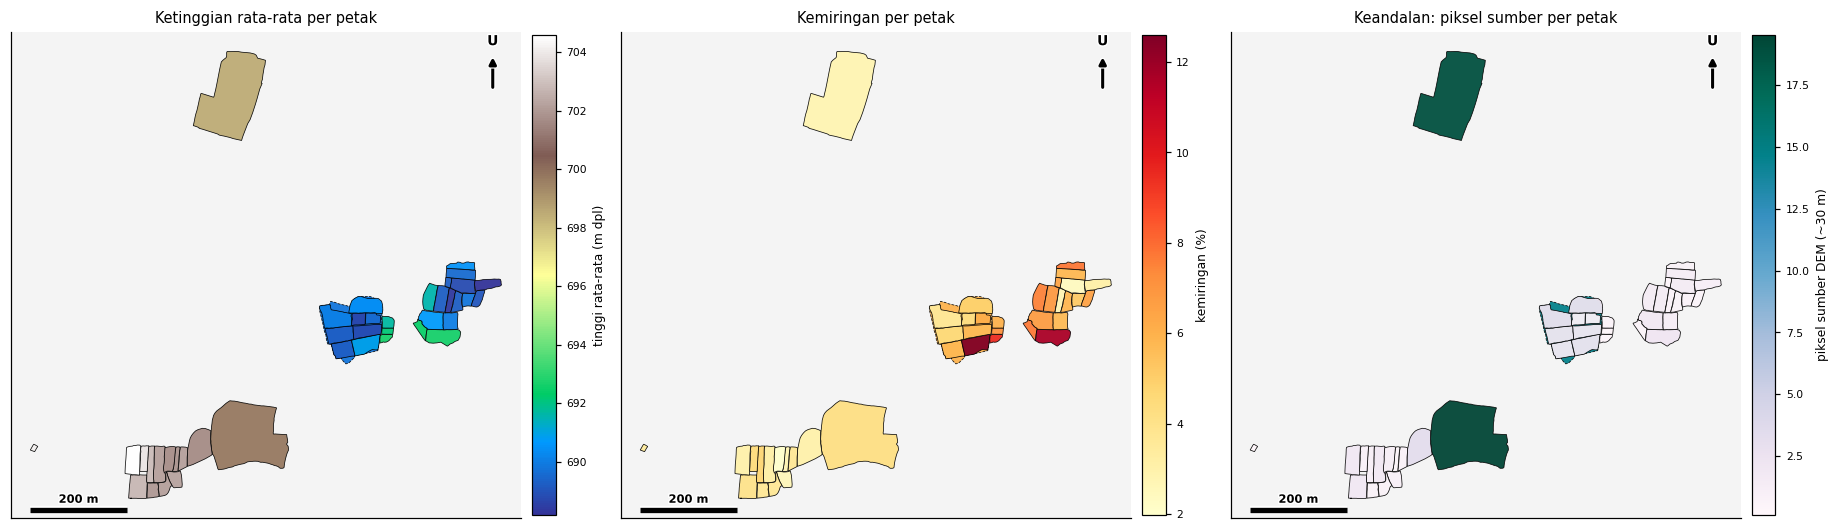

,petak,hamparan,jenis,luas_ha,piksel_sumber,sel_dem,elev_rata_m,beda_tinggi_m,lereng_persen,kelas_lereng,arah_hadap,keandalan_terrain
0,SWH-00,H1,petak,1.7555,19.5,791,699.8,5.5,4.2,landai 3-8%,T,kemiringan (hati-hati)
1,SWH-02,H1,petak,0.2976,3.3,131,701.7,2.1,3.0,landai 3-8%,U,kemiringan (hati-hati)
2,SWH-03,H1,petak,0.0754,0.8,35,702.2,2.1,3.7,landai 3-8%,BL,posisi saja
3,SWH-04,H1,petak,0.0476,0.5,22,701.9,1.7,2.8,datar 0-3%,BL,posisi saja
4,SWH-06,H1,petak,0.1113,1.2,47,701.7,1.2,2.0,datar 0-3%,TL,urutan kasar
5,SWH-07,H1,petak,0.1654,1.8,78,702.2,1.0,3.2,landai 3-8%,T,urutan kasar
6,SWH-08,H1,petak,0.1012,1.1,40,702.9,1.8,4.7,landai 3-8%,T,urutan kasar
7,SWH-09,H1,petak,0.0831,0.9,42,703.9,0.8,4.5,landai 3-8%,T,posisi saja
8,SWH-10,H1,petak,0.0837,0.9,37,702.2,1.3,2.6,datar 0-3%,BL,posisi saja
9,SWH-11,H1,petak,0.0722,0.8,32,702.2,1.1,3.7,landai 3-8%,U,posisi saja


In [16]:
def nilai_petak(nama):
    """Nilai DEM di dalam satu petak; kalau tak ada sel, ambil bilinear di titik berat."""
    m = MASK[nama]
    cx, cy = pusat_poligon(POLI[nama])
    if m.sum() == 0:
        z = float(sampel_dem(ZDEM, [cx], [cy])[0])
        sl = float(sampel_dem(SLOPE_30, [cx], [cy])[0])
        return dict(n_sel=0, elev_min=z, elev_maks=z, elev_rata=z, beda=0.0,
                    lereng_deg=sl, lereng_persen=math.tan(math.radians(sl))*100,
                    aspek=float(sampel_dem(ASPECT, [cx], [cy])[0]),
                    kons=np.nan, akum_ha=float(sampel_dem(LUAS_ALIRAN, [cx], [cy])[0]/1e4))
    z = ZDEM[m]; sl = SLOPE_30[m]; a = ASPECT[m]
    vx, vy = np.sin(np.radians(a)).mean(), np.cos(np.radians(a)).mean()
    return dict(n_sel=int(m.sum()), elev_min=float(z.min()), elev_maks=float(z.max()),
                elev_rata=float(z.mean()), beda=float(z.max()-z.min()),
                lereng_deg=float(sl.mean()),
                lereng_persen=float(math.tan(math.radians(float(sl.mean())))*100),
                aspek=float(math.degrees(math.atan2(vx, vy)) % 360),
                kons=float(math.hypot(vx, vy)),
                akum_ha=float(LUAS_ALIRAN[m].max()/1e4))

LUAS_PIKSEL_SUMBER = 30.0*30.0
baris = []
for n in sorted(POLI):
    v = nilai_petak(n)
    cx, cy = pusat_poligon(POLI[n])
    lo, la = ke_derajat(cx, cy)
    kel = int(np.digitize(v["lereng_persen"], BATAS_KELAS[1:-1]))
    baris.append({
        "petak": n, "hamparan": HAM_DARI[n],
        "jenis": "batas blok" if n in BLOK else "petak",
        "luas_m2": LUAS[n], "luas_ha": LUAS[n]/1e4,
        "keliling_m": keliling(POLI[n]), "simpul": len(POLI[n]),
        "lat": float(la), "lon": float(lo),
        "piksel_sumber": LUAS[n]/LUAS_PIKSEL_SUMBER,
        "sel_dem": v["n_sel"],
        "elev_min_m": v["elev_min"], "elev_maks_m": v["elev_maks"],
        "elev_rata_m": v["elev_rata"], "beda_tinggi_m": v["beda"],
        "lereng_deg": v["lereng_deg"], "lereng_persen": v["lereng_persen"],
        "kelas_lereng": NAMA_KELAS[kel].replace("\n", " "),
        "arah_hadap_deg": v["aspek"],
        "arah_hadap": ARAH_8[int(((v["aspek"]+22.5) % 360)//45)],
        "tangkapan_ha": v["akum_ha"],
    })
df_petak = pd.DataFrame(baris)
df_petak["keandalan_terrain"] = np.where(df_petak["piksel_sumber"] < 1, "posisi saja",
                                  np.where(df_petak["piksel_sumber"] < 3, "urutan kasar",
                                           "kemiringan (hati-hati)"))
df_petak = df_petak.sort_values(["hamparan", "petak"]).reset_index(drop=True)

hanya_petak = df_petak[df_petak["jenis"] == "petak"]
print("=" * 78)
print("           SEBERAPA JAUH TERRAIN PER PETAK BOLEH DIPERCAYA")
print("=" * 78)
print(f"  Satu piksel sumber DEM (~30 m) = {LUAS_PIKSEL_SUMBER:,.0f} m2 = "
      f"{LUAS_PIKSEL_SUMBER/1e4:.3f} ha")
print(f"  Luas petak: median {hanya_petak['luas_m2'].median():,.0f} m2 "
      f"({hanya_petak['piksel_sumber'].median():.1f} piksel sumber)")
for label in ("posisi saja", "urutan kasar", "kemiringan (hati-hati)"):
    n = int((hanya_petak["keandalan_terrain"] == label).sum())
    print(f"    {label:<24}: {n:>2} petak ({100*n/len(hanya_petak):4.0f} %)")
print("-" * 78)
print("  Kesimpulan jujurnya: pada berkas ini terrain PER PETAK tidak bisa dipakai")
print("  merancang apa pun. Yang dapat dipakai adalah terrain PER HAMPARAN (bagian 8-12)")
print("  ditambah POSISI RELATIF petak (hulu/hilir) dari kolom elev_rata_m.")
print("  Untuk desain per petak, satu-satunya jalan adalah pengukuran lapangan.")
print("=" * 78)

# ---------- peta petak: elevasi, kemiringan, keandalan ----------
fig, axes = plt.subplots(1, 3, figsize=(16.8, 6.4))
info = [("elev_rata_m", "terrain", "tinggi rata-rata (m dpl)", "Ketinggian rata-rata per petak"),
        ("lereng_persen", "YlOrRd", "kemiringan (%)", "Kemiringan per petak"),
        ("piksel_sumber", "PuBuGn", "piksel sumber DEM (~30 m)", "Keandalan: piksel sumber per petak")]
for ax, (kol, cmap, satuan, judul) in zip(axes, info):
    v = df_petak.set_index("petak")[kol]
    vmin, vmax = float(v.min()), float(v.max())
    cm = plt.get_cmap(cmap)
    for n in POLI:
        w = cm((v[n]-vmin)/(vmax-vmin) if vmax > vmin else 0.5)
        ax.add_patch(MplPolygon(POLI[n], closed=True, facecolor=w, alpha=0.95,
                                edgecolor="black", lw=0.5,
                                ls=("--" if n in BLOK else "-"), zorder=3))
    sm = plt.cm.ScalarMappable(cmap=cm, norm=plt.Normalize(vmin, vmax))
    cb = plt.colorbar(sm, ax=ax, fraction=0.044, pad=0.02)
    cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    mg = MARGIN_PETA
    ax.set_xlim(X_ALL.min()-mg, X_ALL.max()+mg); ax.set_ylim(Y_ALL.min()-mg, Y_ALL.max()+mg)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_facecolor("#f4f4f4")
    batang_skala(ax, X_ALL.min(), Y_ALL.min()-mg*0.6, 200, "black")
    panah_utara(ax, warna="black")
plt.tight_layout()
simpan_gambar(fig, "08_terrain_per_petak"); plt.show()

df_petak[["petak", "hamparan", "jenis", "luas_ha", "piksel_sumber", "sel_dem",
          "elev_rata_m", "beda_tinggi_m", "lereng_persen", "kelas_lereng",
          "arah_hadap", "keandalan_terrain"]].round(
    {"luas_ha": 4, "piksel_sumber": 1, "elev_rata_m": 1, "beda_tinggi_m": 1,
     "lereng_persen": 1})

---
## 14. Ringkasan dan berkas keluaran

Bagian ini tidak menambah hitungan baru — merangkum, menyimpan, dan menerjemahkan angka
terrain menjadi **konsekuensi** untuk tahap hitungan air berikutnya.

Keluaran yang disimpan ke `note/output-swh-jb-grt/`:

| Berkas | Isi |
|---|---|
| `ringkasan_lokasi.csv` | satu baris angka pokok seluruh lokasi |
| `ringkasan_hamparan.csv` | per hamparan: luas, elevasi, lereng, arah hadap, titik keluar |
| `terrain_per_petak.csv` | 42 baris: luas, elevasi, lereng, arah hadap, keandalan |
| `tumpang_tindih.csv` | pasangan poligon yang beririsan beserta luas irisannya |
| `terrain_grid.csv` | per sel DEM di dalam poligon: koordinat, tinggi, lereng, arah hadap |
| `petak_terrain.kml` | petak diwarnai kelas kemiringan — dibuka langsung di Google Earth |
| `kontur_2m.kml` | garis kontur 2 m |
| `gambar/*.png` | semua peta di atas |

In [17]:
# ---------- ringkasan satu baris ----------
ringkas = {
    "berkas_kml": KML.name,
    "nama_dokumen": nama_dok[0] if nama_dok else "",
    "lat_pusat": round(lat0, 6), "lon_pusat": round(lon0, 6),
    "n_poligon": len(POLI), "n_petak": len(PETAK), "n_blok": len(BLOK),
    "n_hamparan": len(HAMPARAN),
    "nomor_bolong": ";".join(map(str, bolong)),
    "luas_naif_ha": round(LUAS_NAIF/1e4, 4),
    "luas_union_ha": round(LUAS_UNION/1e4, 4),
    "luas_petak_union_ha": round(LUAS_UNION_PETAK/1e4, 4),
    "luas_terhitung_ganda_ha": round((LUAS_NAIF-LUAS_UNION)/1e4, 4),
    "luas_permukaan_ha": round(LUAS_PERMUKAAN/1e4, 4),
    "faktor_lereng": round(FAKTOR_LERENG, 4),
    "bentang_bt_m": round(float(X_ALL.max()-X_ALL.min()), 1),
    "bentang_us_m": round(float(Y_ALL.max()-Y_ALL.min()), 1),
    "elev_min_m": round(Z_MIN, 1), "elev_maks_m": round(Z_MAX, 1),
    "beda_tinggi_lokasi_m": round(BEDA_LOKASI, 1),
    "beda_tinggi_dalam_hamparan_maks_m": round(BEDA_DALAM_MAKS, 1),
    "lereng_rerata_deg": round(SLOPE_RERATA, 2),
    "lereng_rerata_persen": round(SLOPE_PERSEN, 1),
    "lereng_maks_persen": round(float(math.tan(math.radians(float(sl_lahan.max())))*100), 1),
    "kelas_lereng_dominan": KELAS_DOMINAN,
    "arah_hadap_lokasi_deg": round(ASPEK_LOKASI, 1),
    "keterpusatan_lokasi": round(KONS_LOKASI, 3),
    "sebar_tegak_dem_m": round(SEBAR_TEGAK, 2),
    "resolusi_grid_dem_m": round(RES, 2),
    "resolusi_sumber_dem_m": 30,
    "piksel_sumber_per_petak_median": round(float(hanya_petak["piksel_sumber"].median()), 2),
    "sumber_dem": f"Terrarium z{ZOOM_DEM} (SRTM/ASTER)",
}
for i, n in enumerate(NAMA_KELAS):
    ringkas[f"persen_luas_{n.split(chr(10))[0].replace(' ', '_')}"] = round(float(bagi[i]), 1)
df_ringkas = pd.DataFrame([ringkas])

# ---------- ringkasan per hamparan ----------
df_ham_full = (df_ham.drop(columns=["anggota"])
               .merge(df_elev, on="hamparan")
               .merge(df_aspek, on="hamparan")
               .merge(df_alir.drop(columns=["_hi", "_lo", "_out"]), on="hamparan")
               .merge(df_potong[["hamparan", "lereng_searah_persen",
                                 "lereng_melintang_persen", "puntiran_deg"]],
                      on="hamparan", how="left"))
df_ham_full["lereng_rerata_persen"] = [
    round(float(math.tan(math.radians(float(SLOPE_30[MASK_HAM[h]].mean())))*100), 1)
    for h in df_ham_full["hamparan"]]
df_ham_full["anggota"] = [", ".join(sorted(HAMPARAN[h])) for h in df_ham_full["hamparan"]]

df_ringkas.to_csv(OUT_DIR / "ringkasan_lokasi.csv", index=False)
df_ham_full.round(4).to_csv(OUT_DIR / "ringkasan_hamparan.csv", index=False)
df_petak.round(6).to_csv(OUT_DIR / "terrain_per_petak.csv", index=False)
df_tumpang.round(2).to_csv(OUT_DIR / "tumpang_tindih.csv", index=False)

# ---------- grid per sel ----------
sel = DI_LAHAN
lon_g, lat_g = ke_derajat(GX[sel], GY[sel])
milik = np.full(GX.shape, "", object)
for h in HAMPARAN:
    milik[MASK_HAM[h]] = h
pd.DataFrame({
    "hamparan": milik[sel],
    "x_m": np.round(GX[sel], 2), "y_m": np.round(GY[sel], 2),
    "lon": np.round(lon_g, 7), "lat": np.round(lat_g, 7),
    "elev_m": np.round(ZDEM[sel], 2),
    "lereng_deg": np.round(SLOPE_30[sel], 2),
    "lereng_persen": np.round(SLOPE_PCT[sel], 1),
    "arah_hadap_deg": np.round(ASPECT[sel], 1),
    "akumulasi_sel": np.round(AKUM[sel], 0).astype(int),
    "tangkapan_ha": np.round(LUAS_ALIRAN[sel]/1e4, 3),
}).to_csv(OUT_DIR / "terrain_grid.csv", index=False)

# ---------- petak -> KML berwarna kelas kemiringan ----------
ABGR = ["ff50991a", "ff6ad9a6", "ff8be0fe", "ff598dfc", "ff2730d7"]   # aabbggrr
pot = ['<?xml version="1.0" encoding="UTF-8"?>',
       '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
       f'<name>Terrain per petak - {KML.stem}</name>']
for i, n in enumerate(NAMA_KELAS):
    pot.append(f'<Style id="k{i}"><LineStyle><color>ff000000</color><width>1.2</width>'
               f'</LineStyle><PolyStyle><color>{ABGR[i]}</color></PolyStyle></Style>')
pot.append('<Style id="blok"><LineStyle><color>ff00ffff</color><width>2.6</width></LineStyle>'
           '<PolyStyle><fill>0</fill></PolyStyle></Style>')
for _, r in df_petak.iterrows():
    n = r["petak"]
    kel = int(np.digitize(r["lereng_persen"], BATAS_KELAS[1:-1]))
    gaya = "blok" if n in BLOK else f"k{kel}"
    lo_s, la_s = ke_derajat([q[0] for q in POLI[n]] + [POLI[n][0][0]],
                            [q[1] for q in POLI[n]] + [POLI[n][0][1]])
    koord = " ".join(f"{a:.7f},{b:.7f},0" for a, b in zip(lo_s, la_s))
    ket = (f"hamparan {r['hamparan']} | {r['jenis']}<br/>"
           f"luas {r['luas_ha']:.4f} ha ({r['luas_m2']:,.0f} m2)<br/>"
           f"keliling {r['keliling_m']:.0f} m<br/>"
           f"tinggi rata-rata {r['elev_rata_m']:.1f} m dpl "
           f"({r['elev_min_m']:.1f}-{r['elev_maks_m']:.1f})<br/>"
           f"kemiringan {r['lereng_persen']:.1f} % ({r['kelas_lereng']})<br/>"
           f"arah hadap {r['arah_hadap']} ({r['arah_hadap_deg']:.0f} deg)<br/>"
           f"keandalan terrain: {r['keandalan_terrain']} "
           f"({r['piksel_sumber']:.1f} piksel sumber)")
    pot.append(f'<Placemark><name>{n}</name><description><![CDATA[{ket}]]></description>'
               f'<styleUrl>#{gaya}</styleUrl><Polygon><outerBoundaryIs><LinearRing>'
               f'<tessellate>1</tessellate><coordinates>{koord}</coordinates>'
               f'</LinearRing></outerBoundaryIs></Polygon></Placemark>')
pot.append('</Document></kml>')
(OUT_DIR / "petak_terrain.kml").write_text("\n".join(pot), encoding="utf-8")

# ---------- kontur -> KML ----------
fig_t, ax_t = plt.subplots()
lv_k = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
                 ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
cs_k = ax_t.contour(GX, GY, ZDEM, levels=lv_k)
plt.close(fig_t)
pot = ['<?xml version="1.0" encoding="UTF-8"?>',
       '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
       f'<name>Kontur {BEDA_KONTUR:.0f} m - {KML.stem}</name>',
       '<Style id="k"><LineStyle><color>ff00d2ff</color><width>1.6</width></LineStyle></Style>']
n_garis = 0
for lvl, segs in zip(cs_k.levels, cs_k.allsegs):
    for seg in segs:
        if len(seg) < 2:
            continue
        lo_s, la_s = ke_derajat(seg[:, 0], seg[:, 1])
        koord = " ".join(f"{a:.7f},{b:.7f},0" for a, b in zip(lo_s, la_s))
        pot.append(f'<Placemark><name>{lvl:.0f} m</name><styleUrl>#k</styleUrl>'
                   f'<LineString><tessellate>1</tessellate>'
                   f'<coordinates>{koord}</coordinates></LineString></Placemark>')
        n_garis += 1
pot.append('</Document></kml>')
(OUT_DIR / "kontur_2m.kml").write_text("\n".join(pot), encoding="utf-8")

print("Tersimpan:")
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<26} {f.stat().st_size/1024:>9,.1f} KB")
print(f"  gambar/ ({len(GAMBAR_TERSIMPAN)} berkas PNG)")
print(f"\nKontur: {n_garis} garis pada {len(lv_k)} ketinggian, selang {BEDA_KONTUR:.0f} m")
df_ham_full[["hamparan", "n_poligon", "n_petak", "luas_union_ha", "luas_petak_ha",
             "elev_min", "elev_maks", "beda_tinggi_m", "lereng_rerata_persen",
             "arah_hadap", "keterpusatan", "terjun_m"]].round(3)

Tersimpan:
  kontur_2m.kml                  509.4 KB
  petak_terrain.kml               68.1 KB
  ringkasan_hamparan.csv           1.4 KB
  ringkasan_lokasi.csv             0.9 KB
  terrain_grid.csv               243.0 KB
  terrain_per_petak.csv            8.0 KB
  tumpang_tindih.csv               0.4 KB
  gambar/ (8 berkas PNG)

Kontur: 187 garis pada 17 ketinggian, selang 2 m


,hamparan,n_poligon,n_petak,luas_union_ha,luas_petak_ha,elev_min,elev_maks,beda_tinggi_m,lereng_rerata_persen,arah_hadap,keterpusatan,terjun_m
0,H1,13,13,3.202,3.202,696.762,705.000,8.238,3.8,T,0.522,8.238
1,H2,27,26,2.926,2.771,687.906,695.305,7.398,6.3,T,0.160,7.398
2,H3,1,1,1.693,1.693,697.000,699.992,2.992,2.8,TG,0.364,2.992
3,H4,1,1,0.013,0.013,703.902,704.434,0.531,3.4,BD,0.999,0.531


In [18]:
print("=" * 80)
print(f"   RINGKASAN — {KML.stem}   ({LUAS_UNION/1e4:.2f} ha union, "
      f"{len(PETAK)} petak, {len(HAMPARAN)} hamparan)")
print("=" * 80)
print(f"  Letak         : {abs(lat0):.5f} LS, {lon0:.5f} BT | "
      f"{Z_MIN:.0f}-{Z_MAX:.0f} m dpl | bentang "
      f"{X_ALL.max()-X_ALL.min():.0f} x {Y_ALL.max()-Y_ALL.min():.0f} m")
print(f"  LUAS          : {LUAS_UNION/1e4:.4f} ha union "
      f"({LUAS_UNION:,.0f} m2)  <- angka yang dipakai")
print(f"                  {LUAS_UNION_PETAK/1e4:.4f} ha di antaranya luas {len(PETAK)} petak")
print(f"                  jumlah naif 42 poligon {LUAS_NAIF/1e4:.4f} ha "
      f"-> {(LUAS_NAIF-LUAS_UNION)/1e4:.2f} ha terhitung dua kali (batas blok "
      f"{', '.join(BLOK) if BLOK else '-'})")
print(f"                  luas permukaan miring {LUAS_PERMUKAAN/1e4:.4f} ha "
      f"(+{100*(FAKTOR_LERENG-1):.2f} %)")
print(f"  Petak         : {len(PETAK)} petak | terkecil "
      f"{hanya_petak['luas_m2'].min():,.0f} m2 | median "
      f"{hanya_petak['luas_m2'].median():,.0f} m2 | terbesar "
      f"{hanya_petak['luas_m2'].max():,.0f} m2")
print(f"  Beda tinggi   : {BEDA_LOKASI:.1f} m seluruh lokasi, tetapi hanya "
      f"{BEDA_DALAM_MAKS:.1f} m di dalam satu hamparan")
print(f"  Kemiringan    : rata-rata {SLOPE_PERSEN:.1f} % ({SLOPE_RERATA:.1f} deg), maks "
      f"{math.tan(math.radians(float(sl_lahan.max())))*100:.1f} % | dominan {KELAS_DOMINAN}")
print(f"  Arah hadap    : berpencar (keterpusatan {KONS_LOKASI:.2f}) - "
      f"tiap hamparan punya arah sendiri:")
for _, r in df_aspek.iterrows():
    print(f"                  {r['hamparan']}: menghadap {r['arah_hadap']:<3} "
          f"({r['arah_hadap_deg']:.0f} deg), keterpusatan {r['keterpusatan']:.2f}")
print("=" * 80)
print("  KONSEKUENSI UNTUK TAHAP HITUNGAN AIR BERIKUTNYA")
print("=" * 80)
datar_landai = bagi[0] + bagi[1]
print(f"  1. LUAS yang dipakai menghitung air adalah {LUAS_UNION_PETAK/1e4:.2f} ha "
      f"(union {len(PETAK)} petak),")
print(f"     BUKAN {LUAS_NAIF/1e4:.2f} ha. Memakai jumlah naif akan melebihkan kebutuhan")
print(f"     air sekitar {100*(LUAS_NAIF-LUAS_UNION_PETAK)/LUAS_UNION_PETAK:.0f} %.")
if SLOPE_PERSEN <= 8:
    print(f"  2. Lahan tergolong LANDAI: {SLOPE_PERSEN:.1f} % rata-rata, {datar_landai:.0f} % "
          "luas di bawah 8 %.")
    print("     Asumsi genangan tetap per petak masih wajar dipakai - beda dengan lahan")
    print("     berteras curam. Tetap per petak, bukan satu hamparan.")
else:
    print(f"  2. BUKAN sawah datar ({SLOPE_PERSEN:.1f} %): rumus genangan tetap tidak")
    print("     berlaku untuk seluruh hamparan.")
print(f"  3. Hitungan air harus dipecah per HAMPARAN ({len(HAMPARAN)} hamparan), bukan satu")
print(f"     lokasi. Hamparan terpisah sampai {max(min(JARAK[nama_poli.index(a), nama_poli.index(b)] for a in HAMPARAN[h1] for b in HAMPARAN[h2]) for i, h1 in enumerate(list(HAMPARAN)) for h2 in list(HAMPARAN)[i+1:]):.0f} m dan berbeda tinggi sampai "
      f"{df_elev['elev_rata'].max()-df_elev['elev_rata'].min():.0f} m -")
print("     tidak mungkin dilayani satu jaringan gravitasi yang sama.")
berpencar = df_aspek[df_aspek['keterpusatan'] < 0.6]['hamparan'].tolist()
if berpencar:
    print(f"  4. Hamparan {', '.join(berpencar)} arah lerengnya berpencar -> di dalamnya ada")
    print("     lebih dari satu bidang lereng. Air masuk dan keluar tidak lewat satu sisi,")
    print("     jadi jangan rancang satu saluran induk untuk seluruh hamparan itu.")
if RAKSASA:
    print(f"  5. Dari {LUAS_UNION_PETAK/1e4:.2f} ha 'petak', "
          f"{sum(LUAS[n] for n in RAKSASA)/1e4:.2f} ha "
          f"({100*sum(LUAS[n] for n in RAKSASA)/LUAS_UNION_PETAK:.0f} %) masih berupa")
    print(f"     poligon raksasa ({', '.join(RAKSASA)}) yang belum dibagi petak. Untuk luas")
    print("     itu, kebutuhan air hanya bisa dihitung sebagai satu hamparan - bukan per")
    print("     petak - sampai batas petaknya digambar.")
print(f"  6. Terrain per petak TIDAK layak dipakai merancang: median "
      f"{hanya_petak['piksel_sumber'].median():.1f} piksel sumber per petak")
print(f"     ({int((hanya_petak['piksel_sumber'] < 1).sum())} petak bahkan lebih kecil dari "
      f"satu piksel sumber).")
print("     Yang layak: luas (dari KML), posisi hulu/hilir, dan terrain per hamparan.")
print(f"  7. Angka tinggi terjun {df_alir['terjun_m'].min():.1f}-{df_alir['terjun_m'].max():.1f} m "
      f"sepadan dengan ketidakpastian DEM ~{SEBAR_TEGAK:.1f} m.")
print("     Arah aliran boleh dipakai; elevasi ambang pintu WAJIB diukur lapangan.")
print("=" * 80)

   RINGKASAN — SWH-JB-GRT   (7.83 ha union, 41 petak, 4 hamparan)
  Letak         : 7.18619 LS, 107.91157 BT | 688-705 m dpl | bentang 976 x 926 m
  LUAS          : 7.8331 ha union (78,331 m2)  <- angka yang dipakai
                  7.6779 ha di antaranya luas 41 petak
                  jumlah naif 42 poligon 9.0021 ha -> 1.17 ha terhitung dua kali (batas blok SWH-18)
                  luas permukaan miring 7.8442 ha (+0.14 %)
  Petak         : 41 petak | terkecil 127 m2 | median 1,029 m2 | terbesar 17,555 m2
  Beda tinggi   : 17.1 m seluruh lokasi, tetapi hanya 8.2 m di dalam satu hamparan
  Kemiringan    : rata-rata 4.5 % (2.6 deg), maks 15.7 % | dominan landai 3-8%
  Arah hadap    : berpencar (keterpusatan 0.33) - tiap hamparan punya arah sendiri:
                  H1: menghadap T   (96 deg), keterpusatan 0.52
                  H2: menghadap T   (70 deg), keterpusatan 0.16
                  H3: menghadap TG  (129 deg), keterpusatan 0.36
                  H4: menghadap BD  (224 deg)

---
## 15. Asumsi, batasan, dan langkah berikutnya

**Yang dibaca apa adanya (tidak diasumsikan)**

- Jumlah poligon, jumlah simpul, luas tiap poligon, dan tumpang tindihnya — langsung dari
  `SWH-JB-GRT.kml`.
- Penggolongan batas blok vs petak — **dihitung** dari luas tumpang tindih, bukan
  ditebak dari nama atau urutan.
- Pengelompokan hamparan — dihitung dari jarak antar poligon, dengan ambang yang diuji
  kestabilannya.
- Ketinggian, kemiringan, arah hadap, arah aliran — dari DEM Terrarium, dihitung ulang di
  notebook ini.

**Asumsi yang dipakai**

| Asumsi | Nilai | Pengaruh kalau salah |
|---|---|---|
| Proyeksi bidang datar lokal | pusat semua poligon sebagai acuan | diuji di bagian 2: nisbah bola/datar tetap untuk semua poligon, jadi aman walau lokasi terbentang ~1 km |
| Poligon >80 % tertutup poligon lain = batas blok | `AMBANG_BLOK = 0,80` | ambang lebih rendah bisa menggolongkan petak besar yang bertetangga rapat sebagai blok — pada berkas ini pemisahannya tegas (88 % vs 3 %), jadi ambang di mana pun antara 10–80 % memberi hasil sama |
| Poligon >5× median = blok yang belum dibagi | `AMBANG_RAKSASA = 5` | hanya penanda untuk diperiksa manual di citra, tidak mengubah hitungan luas |
| Ambang satu hamparan | `JARAK_HAMPARAN = 60 m` | diuji di bagian 4: hasilnya sama untuk 30–160 m |
| DEM Terrarium mewakili permukaan tanah | — | DEM global adalah model **permukaan**: tajuk pohon dan bangunan ikut terbaca sebagai "tanah" |
| Kemiringan dilaporkan pada skala 30 m | `SLOPE_HALUS_M = 30` | skala lebih halus memberi angka lebih besar tapi sebagian palsu |
| Cekungan DEM adalah derau | *priority flood* | kalau ada embung sungguhan, pengisian ini menghapusnya dari peta aliran |
| Kisi 0,5 m untuk luas gabungan | `LANGKAH_UNION = 0,5` | galat pembulatan tepi < 0,5 % luas petak terkecil |

**Batasan yang harus diingat**

1. **Terrain per petak tidak layak untuk desain.** Median petak hanya seukuran ~1 piksel
   sumber DEM. Angka lereng dan arah hadap per petak di bagian 13 adalah interpolasi,
   bukan pengukuran. Luas tetap sah — luas berasal dari poligon KML.
2. **Beda tinggi seluruh lokasi bukan kemiringan sawah.** Dari beda tinggi lokasi, hanya
   sebagian kecil yang ada di dalam satu hamparan; sisanya beda tinggi antar hamparan
   yang letaknya berjauhan.
3. **Digitasi belum selesai — dua tanda yang saling menguatkan.** Ada nomor petak yang
   bolong (bagian 1), dan ada poligon raksasa berkali-kali median yang batas petaknya
   belum digambar (bagian 3). Jadi jumlah petak di lapangan lebih banyak daripada yang
   ada di file, dan sebagian besar luas belum bisa dihitung per petak.
4. **Alur aliran = skala bentang lahan.** Dipakai untuk arah umum masuk-keluar air, bukan
   untuk menempatkan saluran atau bangunan.
5. **Belum ada satu pun hitungan air.** ETo, Kc, perkolasi, kebutuhan air, debit, dan
   water loss sengaja tidak ada di notebook ini.

**Langkah berikutnya, berurutan**

1. **Periksa poligon yang digolongkan batas blok.** Pastikan di lapangan memang satu blok
   berisi petak-petak, bukan petak yang tergambar dua kali. Ini menentukan luas.
2. **Selesaikan digitasi — ini yang paling menentukan.** Bagi poligon raksasa (bagian 3)
   menjadi petak mengikuti galengan yang sudah terlihat di citra, lengkapi nomor yang
   bolong, dan rapikan petak yang tergambar dua kali di galengan bersama. Selama ini
   belum dikerjakan, sebagian besar luas hanya bisa dihitung sebagai satu hamparan.
3. **Ukur elevasi lapangan** di titik masuk dan titik keluar tiap hamparan, plus beberapa
   titik acuan — menggantikan tinggi terjun dari DEM. Tanpa ini, desain bangunan tidak
   punya dasar.
4. **Konfirmasi sumber air tiap hamparan.** Empat hamparan yang terpisah tidak mungkin
   dilayani satu jaringan gravitasi; harus jelas mana yang dari mata air, mana dari
   saluran, mana dari embung.
5. **Data cuaca setempat** (suhu maks/min, hujan harian) menggantikan data dummy.
6. Baru setelah itu: notebook hitungan air — **per hamparan**, dengan luas union petak
   sebagai dasar, bukan jumlah naif poligon.